In [51]:

import collections.abc
import matplotlib
# parche para reintroducir cbook.iterable
import matplotlib.cbook as cbook
cbook.iterable = lambda x: isinstance(x, collections.abc.Iterable)

In [52]:
def draw_graph(G):
    pos = nx.spring_layout(G, k=1.0, iterations=100, seed=42)

    plt.figure(figsize=(12, 12))
    nx.draw_networkx_nodes(
        G, pos,
        node_color="#ffca28",
        node_size=1500,
        edgecolors="black"
    )
    nx.draw_networkx_labels(
        G, pos,
        font_size=8,
        font_family="sans-serif"
    )
    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='->',
        arrowsize=10,
        width=1.2,
        connectionstyle='arc3,rad=0.1'
    )

    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_color='gray',
        font_size=6
    )

    plt.title("Grafo de llamadas y conexiones de 'firefox' y su cache")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

3.1.5

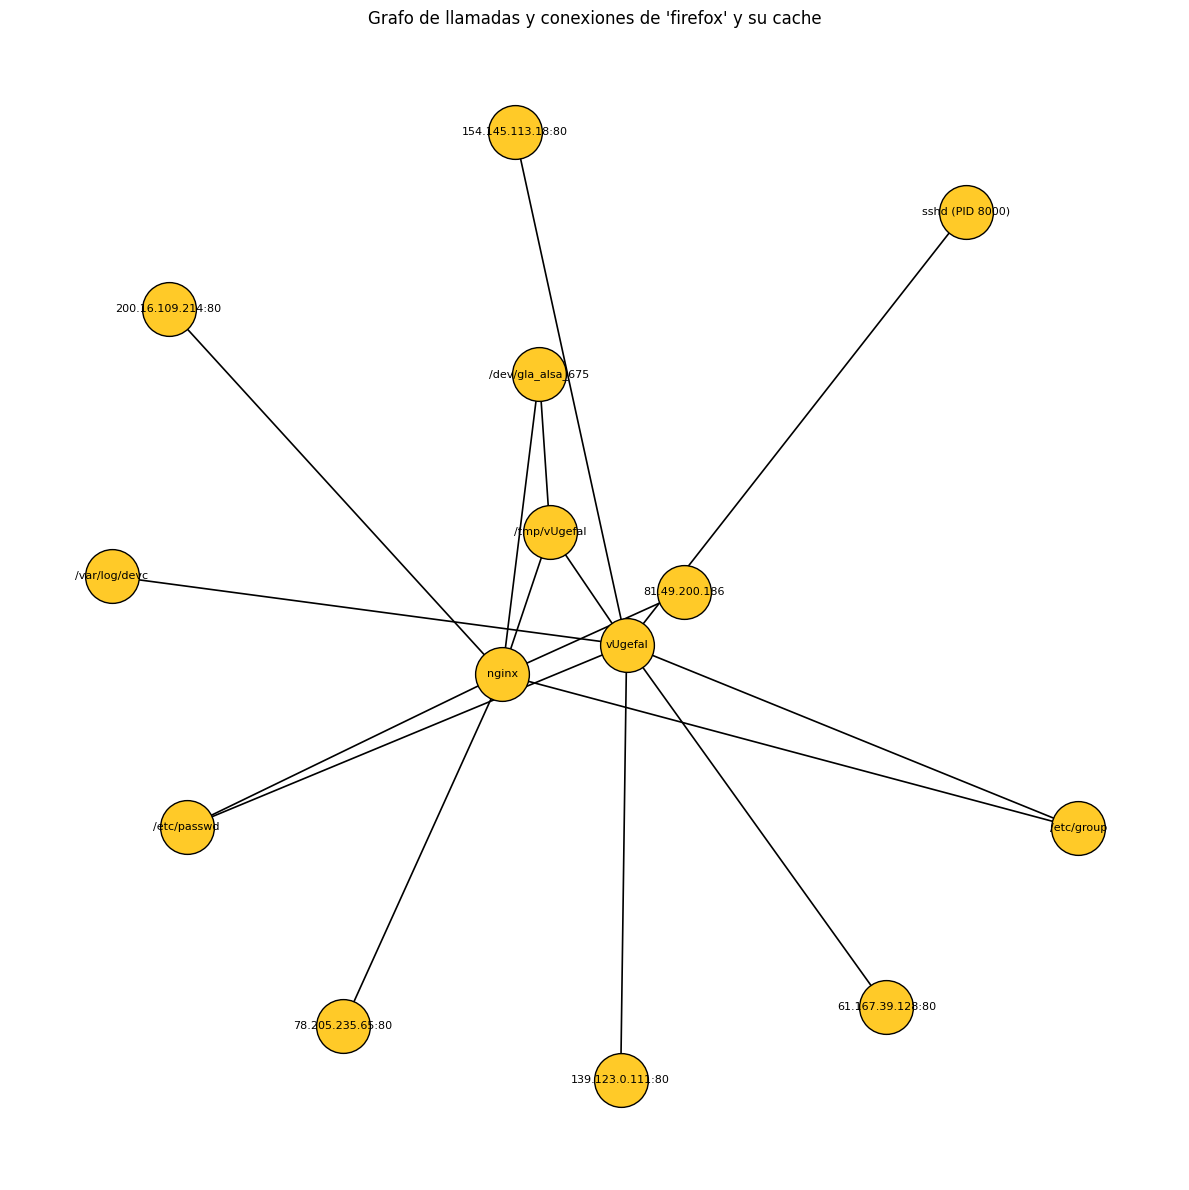

In [53]:
import networkx as nx
import matplotlib.pyplot as plt


G = nx.DiGraph()

nodes = {
    '81.49.200.186': "diamond",
    'nginx': "rectangle",
    '78.205.235.65:80': "diamond",
    '200.16.109.214:80': "diamond",
    '/dev/gla_alsa_675': "ellipse",
    '/tmp/vUgefal': "ellipse",
    'vUgefal': "rectangle",
    '139.123.0.111:80': "diamond",
    '154.145.113.18:80': "diamond",
    '61.167.39.128:80': "diamond",
    '/etc/group': "ellipse",
    '/etc/passwd': "ellipse",
    'sshd (PID 8000)': "rectangle",
    '/var/log/devc': "ellipse"
}
for node, shape in nodes.items():
    G.add_node(node, shape=shape)
    
edges = [
    ('81.49.200.186', 'nginx', 'connect'),                    # connect (exploit :80)
    ('nginx', '78.205.235.65:80', 'connect'),                 # connect (stage1)
    ('nginx', '200.16.109.214:80', 'connect'),                # connect (bc2i)
    ('nginx', '/dev/gla_alsa_675', 'write'),                # write {cmd_exec, cache}
    ('nginx', '/etc/group', 'read'),                       # read
    ('nginx', '/etc/passwd', 'read'),
    ('nginx', '/tmp/vUgefal', 'create'),                      # read
    ('/dev/gla_alsa_675', '/tmp/vUgefal', 'execute'),         # execute (kern_execve)
    ('/tmp/vUgefal', 'vUgefal', 'create'),            # new process (root)
    ('vUgefal', '/etc/group', 'read'),              # read
    ('vUgefal', '139.123.0.111:80', 'connect'),        # connect (netrecon tcp)
    ('vUgefal', '154.145.113.18:80', 'connect'),       # connect (netrecon tcp)
    ('vUgefal', '61.167.39.128:80', 'connect'),        # connect (netrecon tcp)
    ('vUgefal', '/etc/passwd', 'write'),             # inject (devct)
    ('vUgefal', 'sshd (PID 8000)', 'create'),         # inject (devct)
    ('vUgefal', '/var/log/devc', 'write'),            # write / chmod
]

for src, dst, action in edges:
    G.add_edge(src, dst, action=action)



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_1.gml")


3.2.5

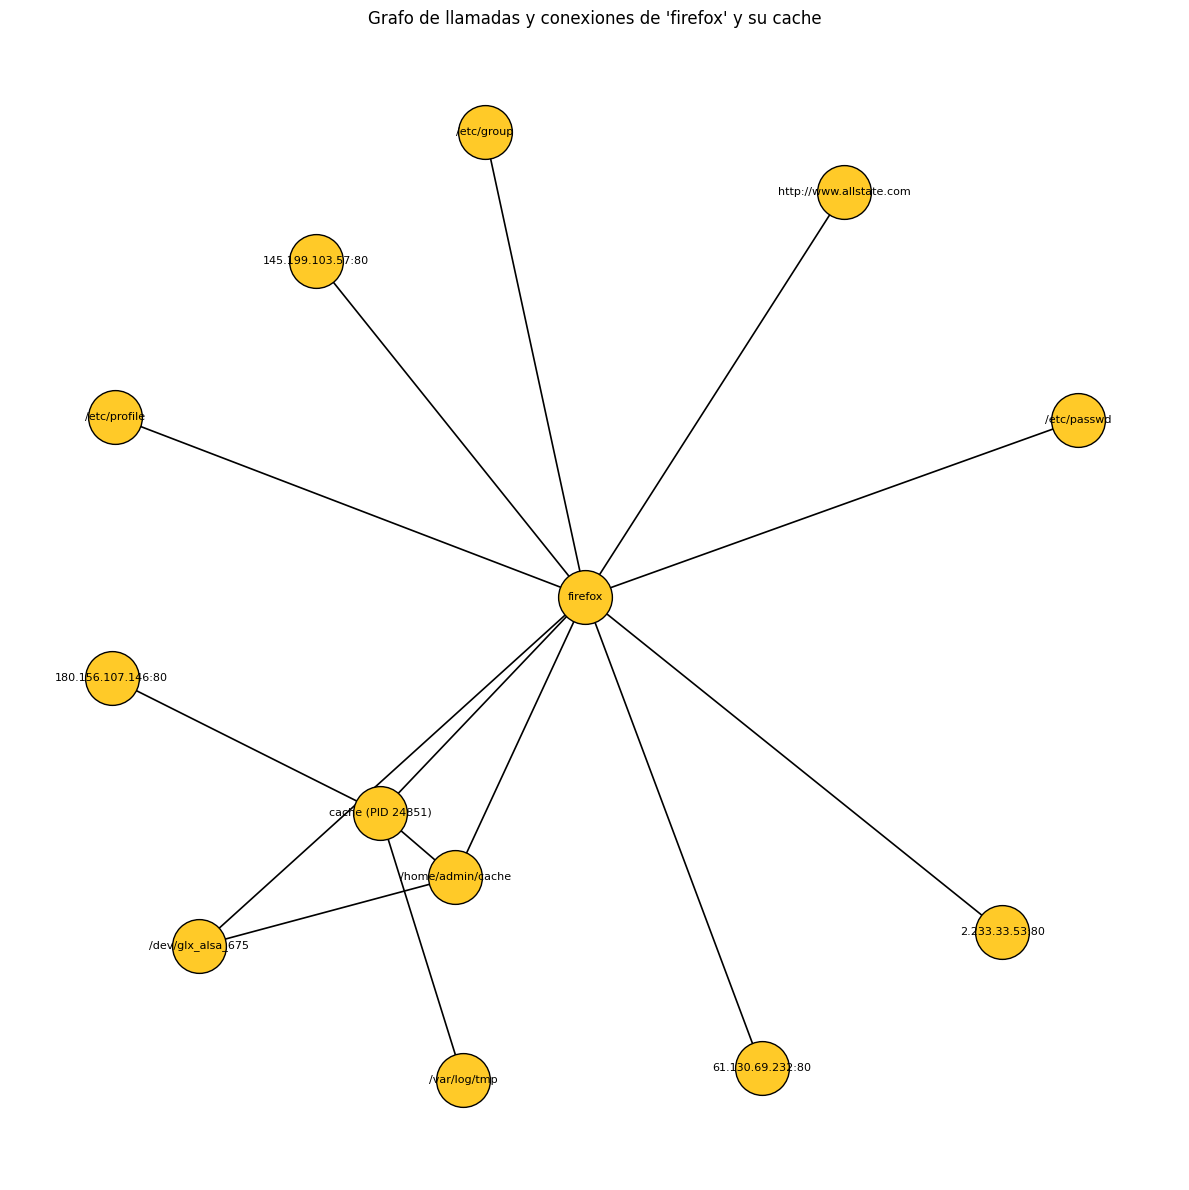

In [54]:
import networkx as nx

G = nx.DiGraph()

# nodos
# procesos
G.add_node("firefox", shape="rectangle")
G.add_node("cache (PID 24851)", shape="rectangle")

# ficheros
for fn in [
    "/dev/glx_alsa_675",
    "/etc/profile",
    "/etc/passwd",
    "/etc/group",
    "/home/admin/cache",
    "/var/log/tmp"
]:
    G.add_node(fn, shape="ellipse")

# conexiones/IP/URL
for cn in [
    "145.199.103.57:80",
    "61.130.69.232:80",
    "2.233.33.53:80",
    "180.156.107.146:80",
    "http://www.allstate.com"
]:
    G.add_node(cn, shape="diamond")

# aristas desde firefox
G.add_edge("firefox", "/dev/glx_alsa_675", action="write")
G.add_edge("firefox", "145.199.103.57:80", action="connect")
G.add_edge("firefox", "61.130.69.232:80", action="connect")
G.add_edge("firefox", "61.130.69.232:80", action="connect")
G.add_edge("firefox", "61.130.69.232:80", action="connect")
G.add_edge("firefox", "2.233.33.53:80", action="connect")
G.add_edge("firefox", "2.233.33.53:80", action="connect")
G.add_edge("firefox", "/etc/profile", action="read")
G.add_edge("firefox", "/etc/passwd", action="read")
G.add_edge("firefox", "/etc/group", action="read")
G.add_edge("firefox", "/home/admin/cache", action="write")
G.add_edge("firefox", "/home/admin/cache", action="read")
G.add_edge("firefox", "/home/admin/cache", action="write")
G.add_edge("firefox", "http://www.allstate.com", action="connect")

# aristas desde cache (PID 24851)
G.add_edge("firefox", "cache (PID 24851)", action="create")
G.add_edge("cache (PID 24851)", "/home/admin/cache", action="write")
G.add_edge("cache (PID 24851)", "/var/log/tmp", action="write")
G.add_edge("cache (PID 24851)", "180.156.107.146:80", action="connect")

G.add_edge("/home/admin/cache", "/dev/glx_alsa_675", action="write")





draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_2.gml")

3.3.5

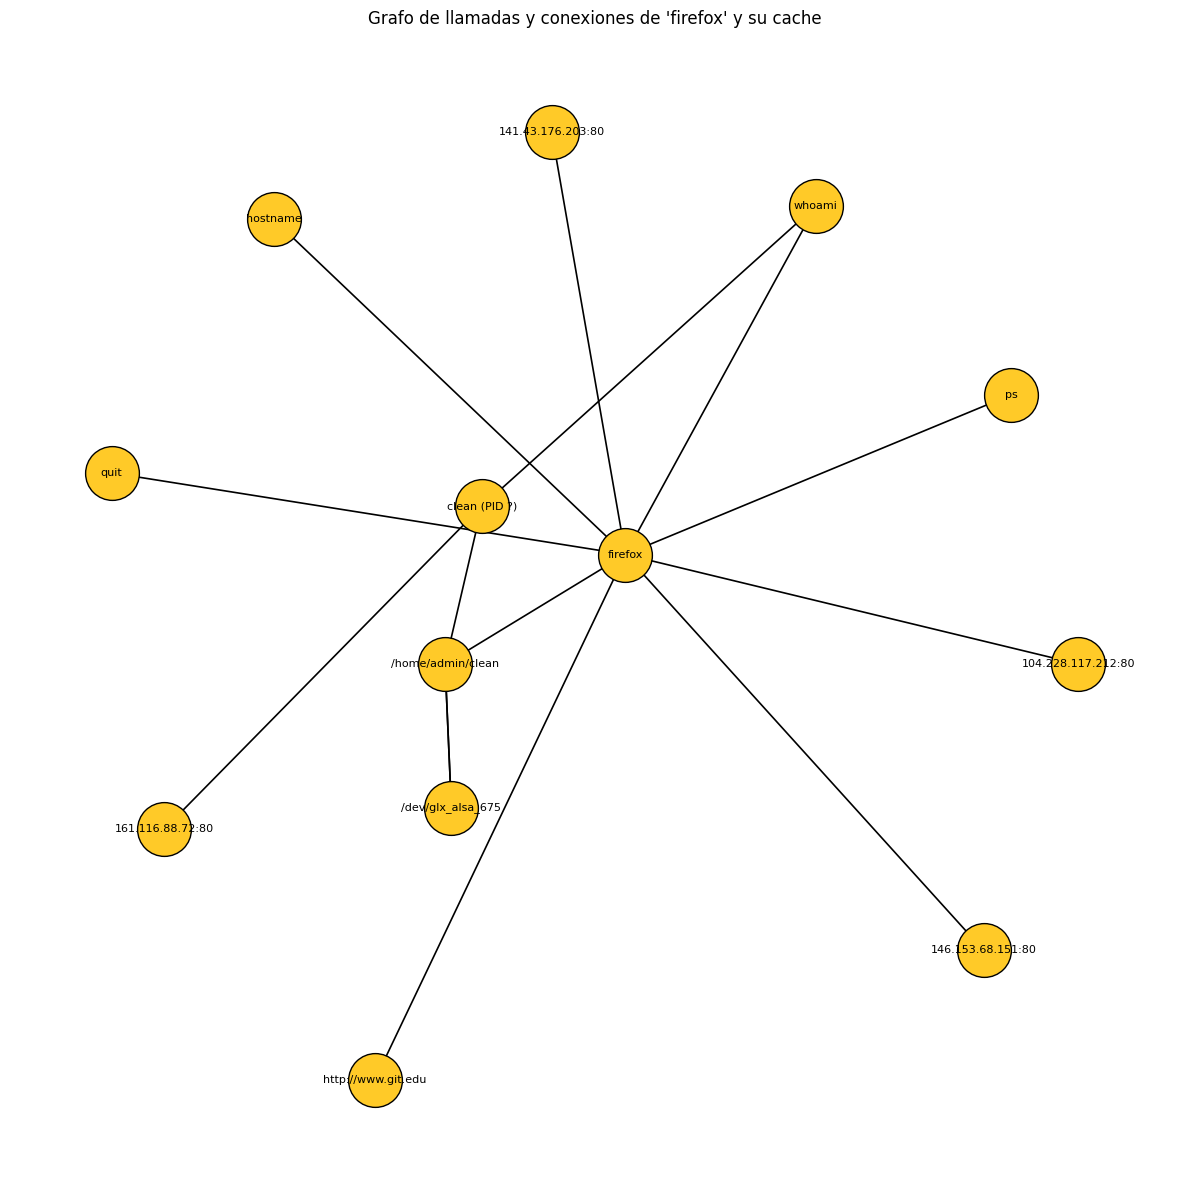

In [55]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo dirigido
G = nx.DiGraph()

# Añadir nodos con atributos (shape)
nodes = {
    "141.43.176.203:80": "diamond",
    "104.228.117.212:80": "diamond",
    "http://www.git.edu": "diamond",
    "quit": "rectangle",
    "ps": "rectangle",
    "hostname": "rectangle",
    "146.153.68.151:80": "diamond",
    "firefox": "rectangle",
    "/dev/glx_alsa_675": "ellipse",
    "/home/admin/clean": "ellipse",
    "clean (PID ?)": "rectangle",
    "161.116.88.72:80": "diamond",
    "whoami": "rectangle"
}

for node, shape in nodes.items():
    G.add_node(node, shape=shape)

# Añadir aristas con la propiedad 'action'
edges = [
    ("firefox", "141.43.176.203:80", "connect"),
    ("firefox", "104.228.117.212:80", "connect"),
    ("firefox", "http://www.git.edu", "connect"),
    ("firefox", "quit", "execute"),
    ("firefox", "ps", "execute"),
    ("firefox", "hostname", "execute"),
    ("firefox", "146.153.68.151:80", "connect"),
    ("firefox", "/home/admin/clean", "write"),
    ("/home/admin/clean", "clean (PID ?)", "create"),
    ("clean (PID ?)", "161.116.88.72:80", "connect"),
    ("clean (PID ?)", "whoami", "execute"),
    ("/home/admin/clean", "/dev/glx_alsa_675", "execute"),
    ("/dev/glx_alsa_675", "/home/admin/clean", "write"),
    ("firefox", "whoami", "execute")
]

for src, dst, action in edges:
    G.add_edge(src, dst, action=action)




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_3.gml")

3.4.5

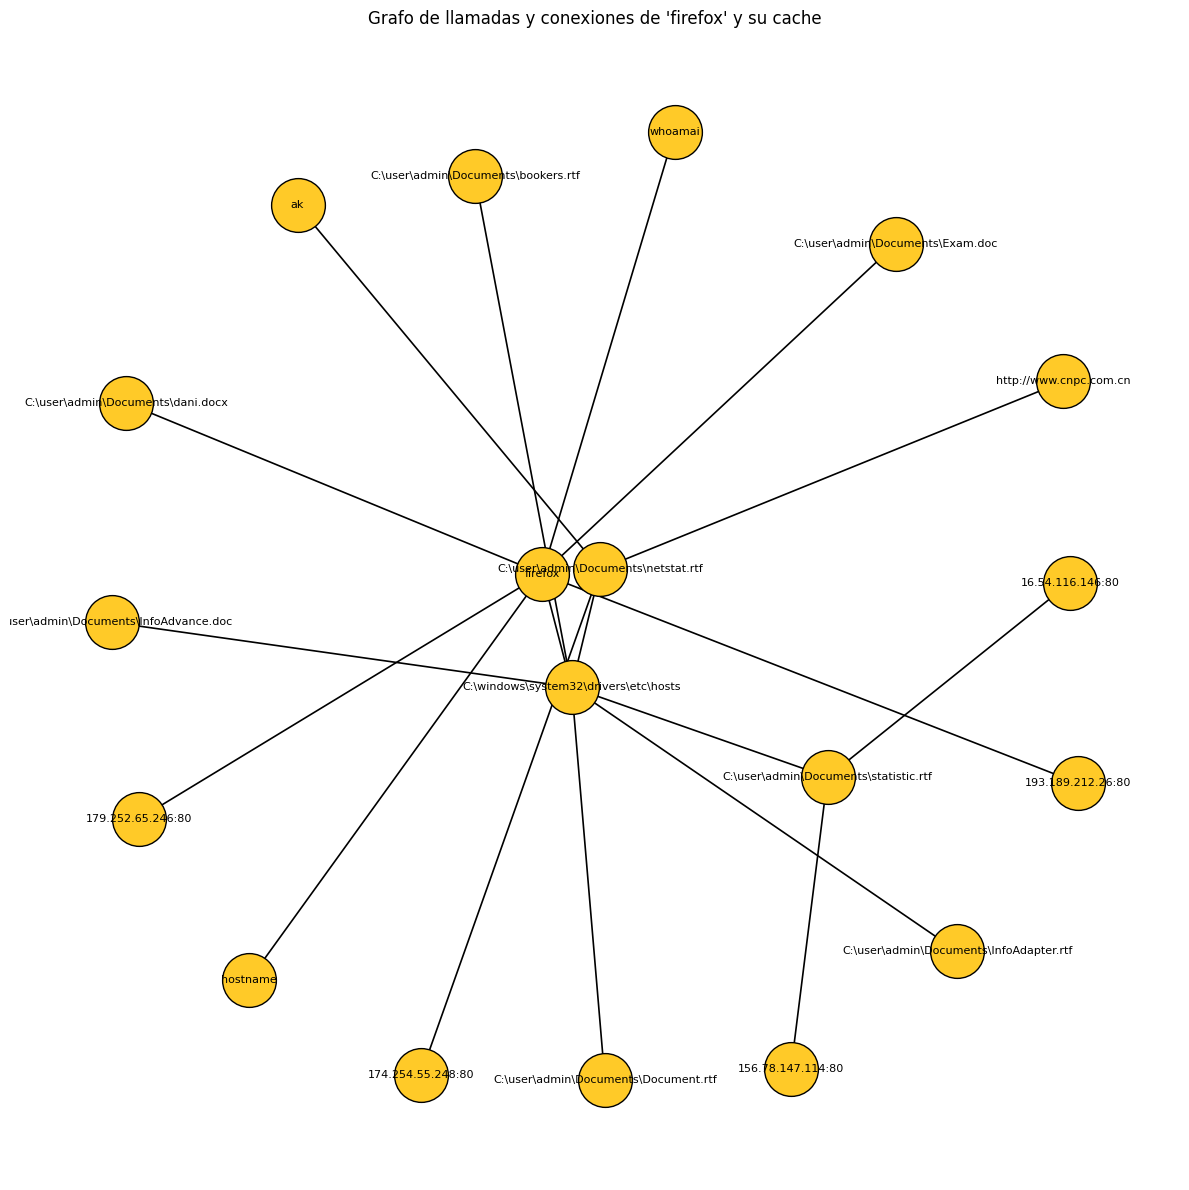

In [56]:
# Crear grafo dirigido para la nueva imagen
G = nx.DiGraph()

# Nodos y sus atributos shape correspondientes
nodes2 = {
    "whoamai": "rectangle",
    "firefox": "rectangle",
    "hostname": "rectangle",
    "C:\\user\\admin\\Documents\\dani.docx": "ellipse",
    "C:\\user\\admin\\Documents\\Exam.doc": "ellipse",
    "C:\\windows\\system32\\drivers\\etc\\hosts": "ellipse",
    "193.189.212.26:80": "diamond",
    "179.252.65.246:80": "diamond",
    "C:\\user\\admin\\Documents\\bookers.rtf": "ellipse",
    "C:\\user\\admin\\Documents\\Document.rtf": "ellipse",
    "C:\\user\\admin\\Documents\\InfoAdapter.rtf": "ellipse",
    "C:\\user\\admin\\Documents\\InfoAdvance.doc": "ellipse",
    "C:\\user\\admin\\Documents\\netstat.rtf": "ellipse",
    "C:\\user\\admin\\Documents\\statistic.rtf": "ellipse",
    "156.78.147.114:80": "diamond",
    "16.54.116.146:80": "diamond",
    "ak": "diamond",
    "http://www.cnpc.com.cn": "diamond",
    "174.254.55.248:80": "diamond"
}

for node, shape in nodes2.items():
    G.add_node(node, shape=shape)

# Aristas y sus acciones asociadas
edges2 = [
    ("firefox", "whoamai", "execute"),
    ("firefox", "hostname", "execute"),
    ("firefox", "C:\\user\\admin\\Documents\\dani.docx", "read"),
    ("firefox", "C:\\user\\admin\\Documents\\Exam.doc", "read"),
    ("firefox", "C:\\windows\\system32\\drivers\\etc\\hosts", "execute"),
    ("firefox", "193.189.212.26:80", "connect"),
    ("firefox", "179.252.65.246:80", "connect"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\bookers.rtf", "execute"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\Document.rtf", "execute"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\InfoAdapter.rtf", "execute"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\InfoAdvance.doc", "read"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\netstat.rtf", "read"),
    ("C:\\windows\\system32\\drivers\\etc\\hosts", "C:\\user\\admin\\Documents\\statistic.rtf", "execute"),
    ("C:\\user\\admin\\Documents\\statistic.rtf", "156.78.147.114:80", "connect"),
    ("C:\\user\\admin\\Documents\\statistic.rtf", "16.54.116.146:80", "connect"),
    ("C:\\user\\admin\\Documents\\netstat.rtf", "ak", "execute"),
    ("C:\\user\\admin\\Documents\\netstat.rtf", "http://www.cnpc.com.cn", "connect"),
    ("C:\\user\\admin\\Documents\\netstat.rtf", "174.254.55.248:80", "connect")
]

for src, dst, action in edges2:
    G.add_edge(src, dst, action=action)


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_4.gml")

3.6.5

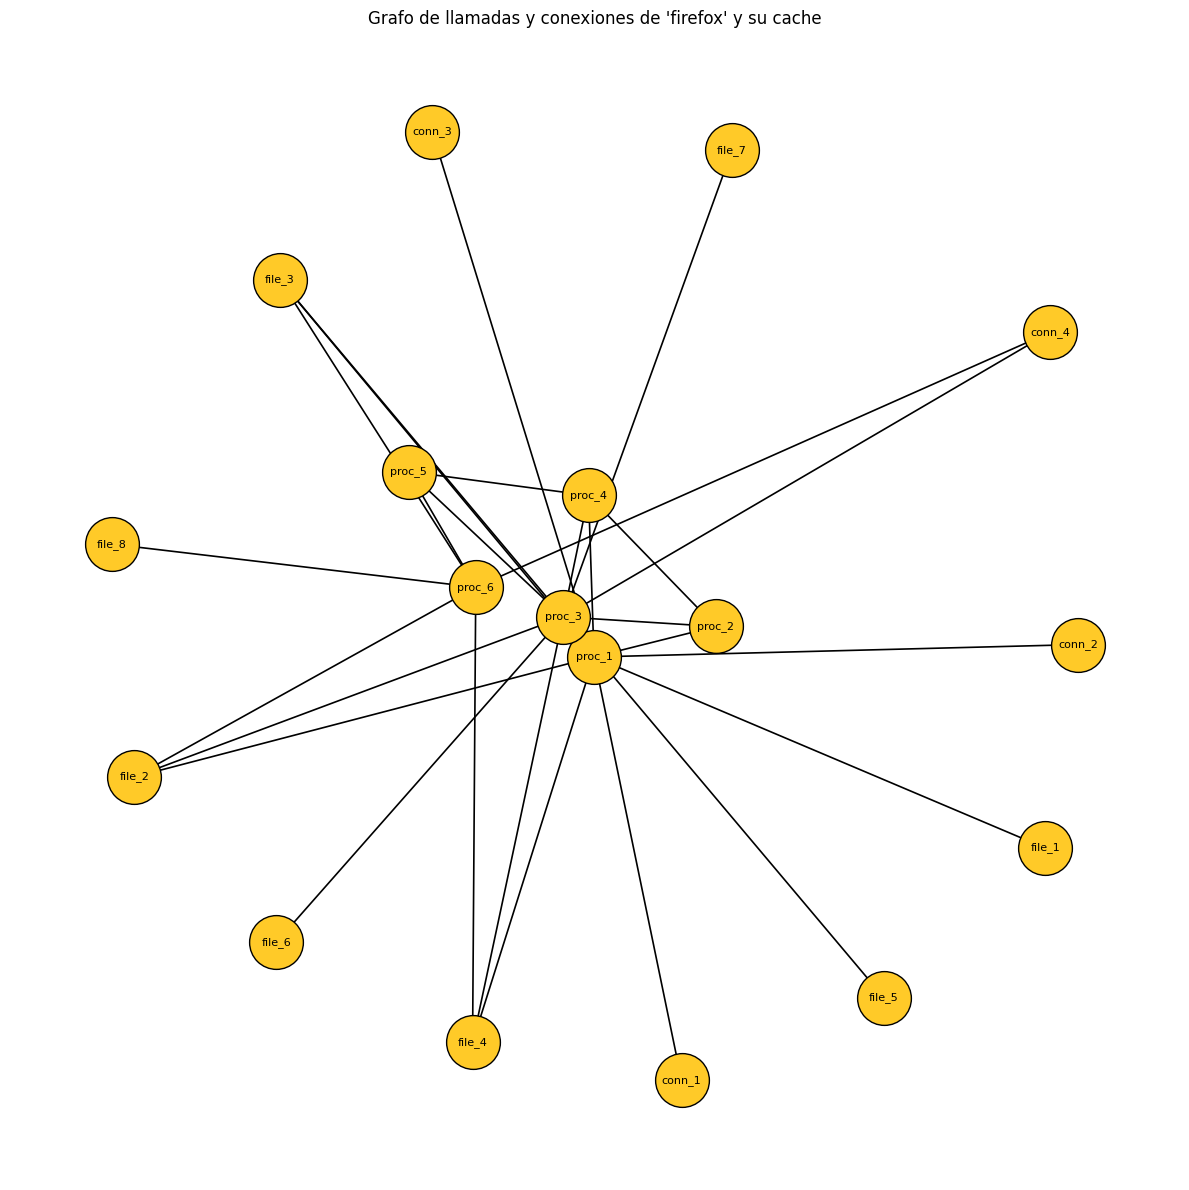

In [57]:




import networkx as nx

# Creamos un grafo dirigido
G = nx.DiGraph()

# -----------------------
# 1️⃣  Definimos los nodos
# -----------------------
nodes = {
    # Procesos (rectangle)
    "proc_1":   {"shape": "rectangle"},
    "proc_2":   {"shape": "rectangle"},
    "proc_3":   {"shape": "rectangle"},
    "proc_4":   {"shape": "rectangle"},
    "proc_5":   {"shape": "rectangle"},
    "proc_6":   {"shape": "rectangle"},

    # Archivos (ellipse)
    "file_1":     {"shape": "ellipse"},
    "file_2":     {"shape": "ellipse"},
    "file_3":     {"shape": "ellipse"},
    "file_4":     {"shape": "ellipse"},
    "file_5":     {"shape": "ellipse"},
    "file_6":     {"shape": "ellipse"},
    "file_7":     {"shape": "ellipse"},
    "file_8":     {"shape": "ellipse"},

    # Conexiones / IPs / URLs (diamond)
    "conn_1":     {"shape": "diamond"},
    "conn_2":     {"shape": "diamond"},
    "conn_3":     {"shape": "diamond"},
    "conn_4":     {"shape": "diamond"},
}

# Añadimos los nodos con sus atributos
G.add_nodes_from([(n, attrs) for n, attrs in nodes.items()])

# -----------------------
# 2️⃣  Definimos las aristas
# -----------------------
edges = [
    ("proc_1",   "conn_1",   {"action": "connect"}),
    ("proc_1",   "conn_2",   {"action": "connect"}),
    ("proc_1",   "conn_3",   {"action": "connect"}),
    ("proc_1",   "proc_2",   {"action": "create"}),
    ("proc_1",   "proc_4",   {"action": "create"}),
    ("proc_1",   "file_1",   {"action": "read"}),
    ("proc_1",   "file_2",   {"action": "write"}),
    ("proc_1",   "file_3",   {"action": "write"}),
    ("proc_1",   "file_4",   {"action": "write"}),
    
    ("proc_2",   "proc_3",   {"action": "create"}),

    ("proc_3",   "proc_4",   {"action": "read"}),
    ("proc_3",   "file_5",   {"action": "read"}),
    ("proc_3",   "file_6",   {"action": "read"}),
    ("proc_3",   "file_7",   {"action": "read"}),
    ("proc_3",   "file_2",   {"action": "write"}),
    ("proc_3",   "file_4",   {"action": "write"}),
    ("proc_3",   "proc_5",   {"action": "create"}),
    ("proc_3",   "conn_4",   {"action": "connect"}),
    ("proc_3",   "file_3",   {"action": "write"}),

    ("proc_4",   "proc_2",   {"action": "read"}),
    ("proc_4",   "proc_5",   {"action": "read"}),

    ("proc_5",   "proc_6",   {"action": "create"}),
    ("proc_6",   "file_2",   {"action": "read"}),
    ("proc_6",   "file_4",   {"action": "read"}),
    ("proc_6",   "conn_4",   {"action": "connect"}),
    ("proc_6",   "file_8",   {"action": "read"}),
    ("proc_6",   "file_3",   {"action": "read"}),
]

# Añadimos las aristas con sus atributos
G.add_edges_from(edges)


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_6.gml")



3.8.5

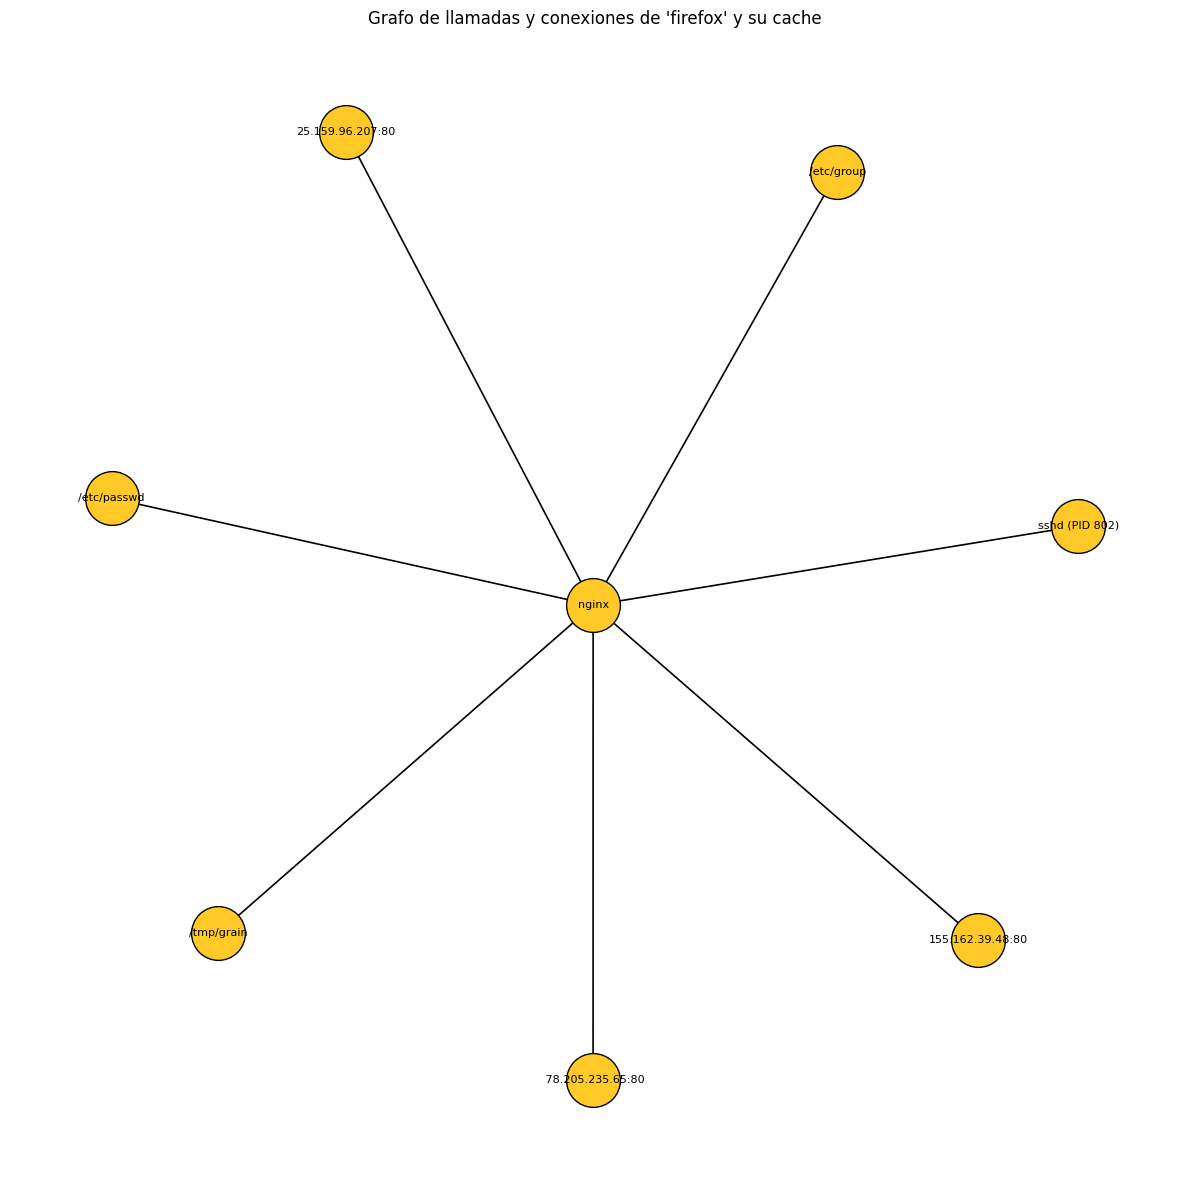

In [58]:
import networkx as nx

G = nx.DiGraph()

# — nodos —

# procesos (rectangle)
G.add_node("nginx", shape="rectangle")
G.add_node("sshd (PID 802)", shape="rectangle")

# ficheros (ellipse)
for fn in ["/tmp/grain", "/etc/passwd", "/etc/group"]:
    G.add_node(fn, shape="ellipse")

# conexiones/IP (diamond)
for cn in ["25.159.96.207:80", "155.162.39.48:80", " 78.205.235.65:80"]:
    G.add_node(cn, shape="diamond")

# — aristas —

# nginx realiza varias operaciones locales
G.add_edge("nginx", "/tmp/grain", action="write")
G.add_edge("nginx", "/etc/passwd", action="read")
G.add_edge("nginx", "/etc/group", action="read")

# nginx se conecta a varios servidores remotos
G.add_edge("nginx", "25.159.96.207:80", action="connect")
G.add_edge("nginx", "155.162.39.48:80", action="connect")
G.add_edge("nginx", " 78.205.235.65:80", action="connect")

# inyección y efecto cascada
G.add_edge("nginx", "sshd (PID 802)", action="write")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_8.gml")

3.10.5

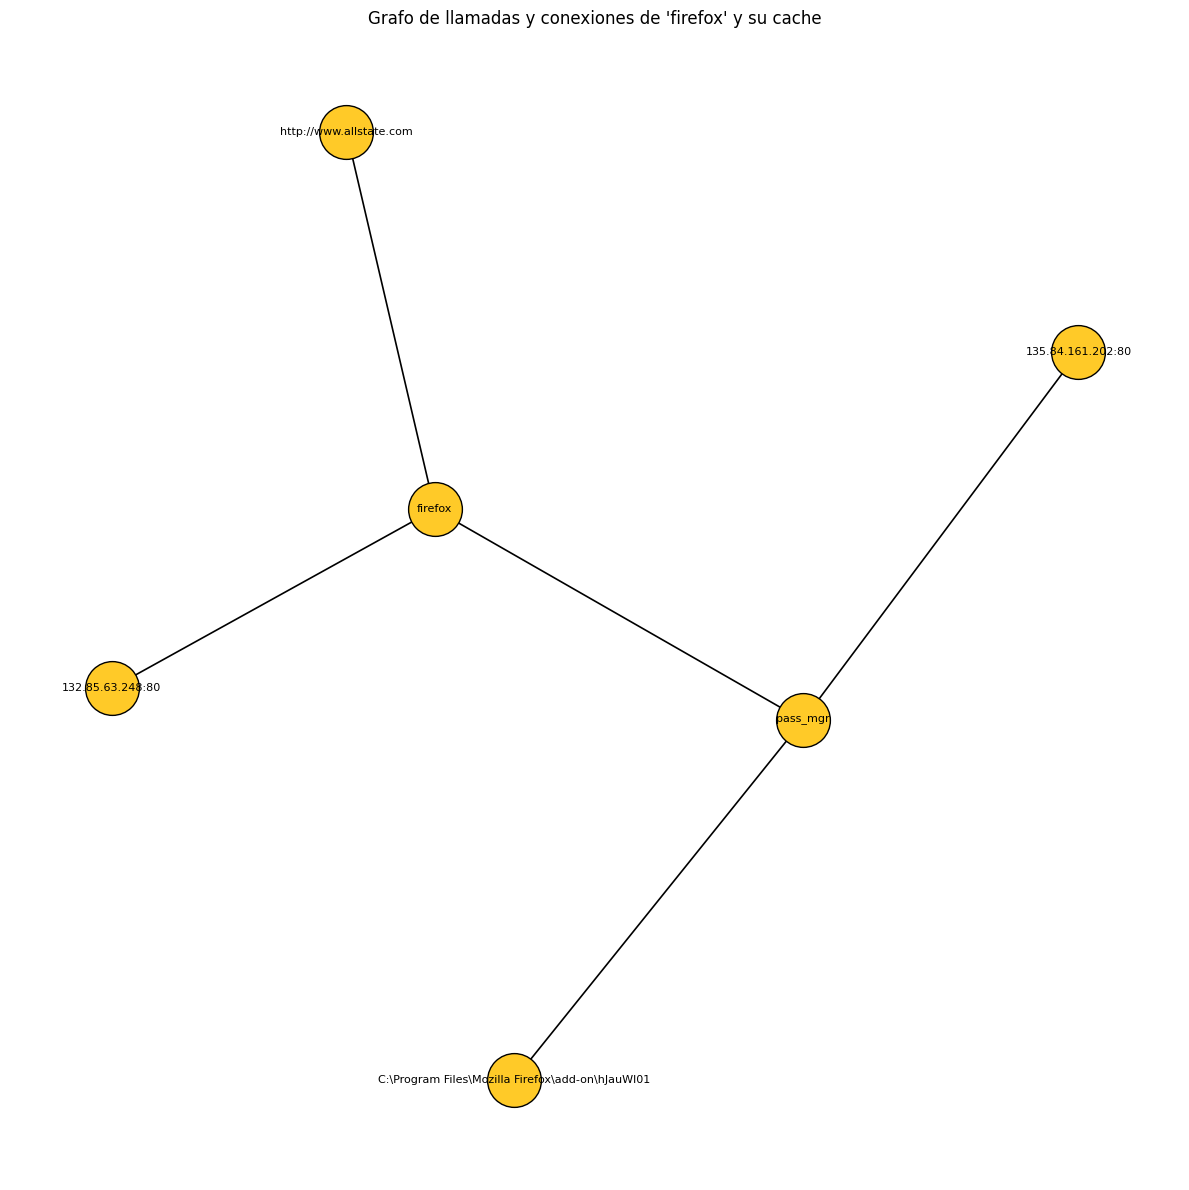

In [59]:
import networkx as nx

G = nx.DiGraph()

# — nodos —

# procesos (rectangle)
G.add_node("firefox", shape="rectangle")
G.add_node("pass_mgr", shape="rectangle")

# fichero local (ellipse)
G.add_node(r"C:\Program Files\Mozilla Firefox\add-on\hJauWl01", shape="ellipse")

# conexiones e URLs (diamond)
G.add_node("132.85.63.248:80", shape="diamond")
G.add_node("135.84.161.202:80", shape="diamond")
G.add_node("http://www.allstate.com", shape="diamond")

# — aristas —

# firefox dispara la carga de pass_mgr y navegación
G.add_edge("firefox", "pass_mgr", action="create")
G.add_edge("firefox", "132.85.63.248:80", action="connect")
G.add_edge("firefox", "http://www.allstate.com", action="connect")

# pass_mgr intenta ejecutar y escribir en el add-on
G.add_edge("pass_mgr", r"C:\Program Files\Mozilla Firefox\add-on\hJauWl01",
           action="execute")
G.add_edge("pass_mgr", r"C:\Program Files\Mozilla Firefox\add-on\hJauWl01",
           action="write")

# pass_mgr se conecta a su servidor de segunda etapa
G.add_edge("pass_mgr", "135.84.161.202:80", action="connect")




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_10.gml")

3.11.7

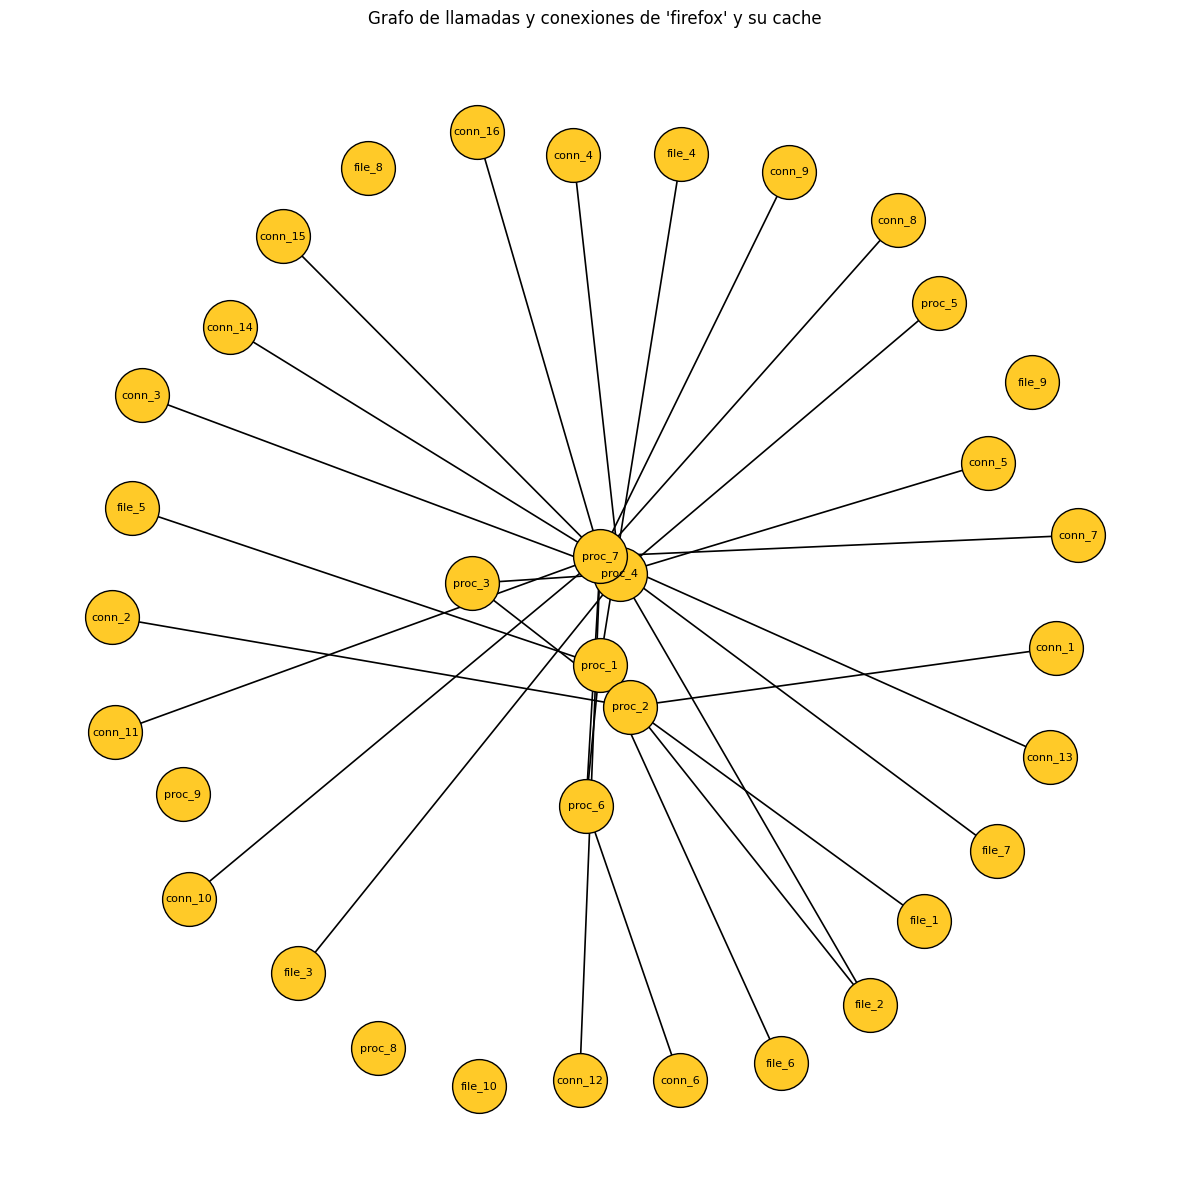

In [60]:

import networkx as nx

# Creamos un grafo dirigido
G = nx.DiGraph()

# -----------------------
# 1️⃣  Definimos los nodos
# -----------------------
nodes = {
    # Procesos (rectangle)
    "proc_1":   {"shape": "rectangle"},
    "proc_2":   {"shape": "rectangle"},
    "proc_3":   {"shape": "rectangle"},
    "proc_4":   {"shape": "rectangle"},
    "proc_5":   {"shape": "rectangle"},
    "proc_6":   {"shape": "rectangle"},
    "proc_7":   {"shape": "rectangle"},
    "proc_8":   {"shape": "rectangle"},
    "proc_9":   {"shape": "rectangle"},

    # Archivos (ellipse)
    "file_1":     {"shape": "ellipse"},
    "file_2":     {"shape": "ellipse"},
    "file_3":     {"shape": "ellipse"},
    "file_4":     {"shape": "ellipse"},
    "file_5":     {"shape": "ellipse"},
    "file_6":     {"shape": "ellipse"},
    "file_7":     {"shape": "ellipse"},
    "file_8":     {"shape": "ellipse"},
    "file_9":     {"shape": "ellipse"},
    "file_10":     {"shape": "ellipse"},

    # Conexiones / IPs / URLs (diamond)
    "conn_1":     {"shape": "diamond"},
    "conn_2":     {"shape": "diamond"},
    "conn_3":     {"shape": "diamond"},
    "conn_4":     {"shape": "diamond"},
    "conn_5":     {"shape": "diamond"},
    "conn_6":     {"shape": "diamond"},
    "conn_7":     {"shape": "diamond"},
    "conn_8":     {"shape": "diamond"},
    "conn_9":     {"shape": "diamond"},
    "conn_10":     {"shape": "diamond"},
    "conn_11":     {"shape": "diamond"},
    "conn_12":     {"shape": "diamond"},
    "conn_13":     {"shape": "diamond"},
    "conn_14":     {"shape": "diamond"},
    "conn_15":     {"shape": "diamond"},
    "conn_16":     {"shape": "diamond"},
}

# Añadimos los nodos con sus atributos
G.add_nodes_from([(n, attrs) for n, attrs in nodes.items()])

# -----------------------
# 2️⃣  Definimos las aristas
# -----------------------
edges = [
    ("proc_1",   "file_2",   {"action": "write"}),
    ("proc_1",   "file_4",   {"action": "write"}),
    ("proc_1",   "file_5",   {"action": "read"}),
    ("proc_1",   "file_6",   {"action": "write"}),
    ("proc_1",   "proc_6",   {"action": "create"}),
    
    ("proc_6",   "proc_7",   {"action": "create"}),
    ("proc_6",   "conn_6",   {"action": "connect"}),

    ("proc_7",   "conn_7",   {"action": "connect"}),
    ("proc_7",   "conn_8",   {"action": "connect"}),
    ("proc_7",   "conn_9",   {"action": "connect"}),
    ("proc_7",   "conn_10",   {"action": "connect"}),
    ("proc_7",   "conn_11",   {"action": "connect"}),
    ("proc_7",   "conn_12",   {"action": "connect"}),
    ("proc_7",   "conn_13",   {"action": "connect"}),
    ("proc_7",   "conn_14",   {"action": "connect"}),
    ("proc_7",   "conn_15",   {"action": "connect"}),
    ("proc_7",   "conn_16",   {"action": "connect"}),
    ("proc_7",   "file_7",   {"action": "read"}),

    ("proc_2",   "file_1",   {"action": "read"}),
    ("proc_2",   "conn_1",   {"action": "connect"}),
    ("proc_2",   "proc_3",   {"action": "read"}),
    ("proc_2",   "conn_2",   {"action": "connect"}),
    ("proc_3",   "proc_4",   {"action": "create"}),

    ("proc_4",   "conn_3",   {"action": "connect"}),
    ("proc_4",   "conn_4",   {"action": "connect"}),
    ("proc_4",   "conn_5",   {"action": "connect"}),
    ("proc_4",   "proc_5",   {"action": "create"}),
    ("proc_4",   "file_2",   {"action": "read"}),
    ("proc_4",   "file_3",   {"action": "read"}),
]

# Añadimos las aristas con sus atributos
G.add_edges_from(edges)


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_11.gml")


3.13.6

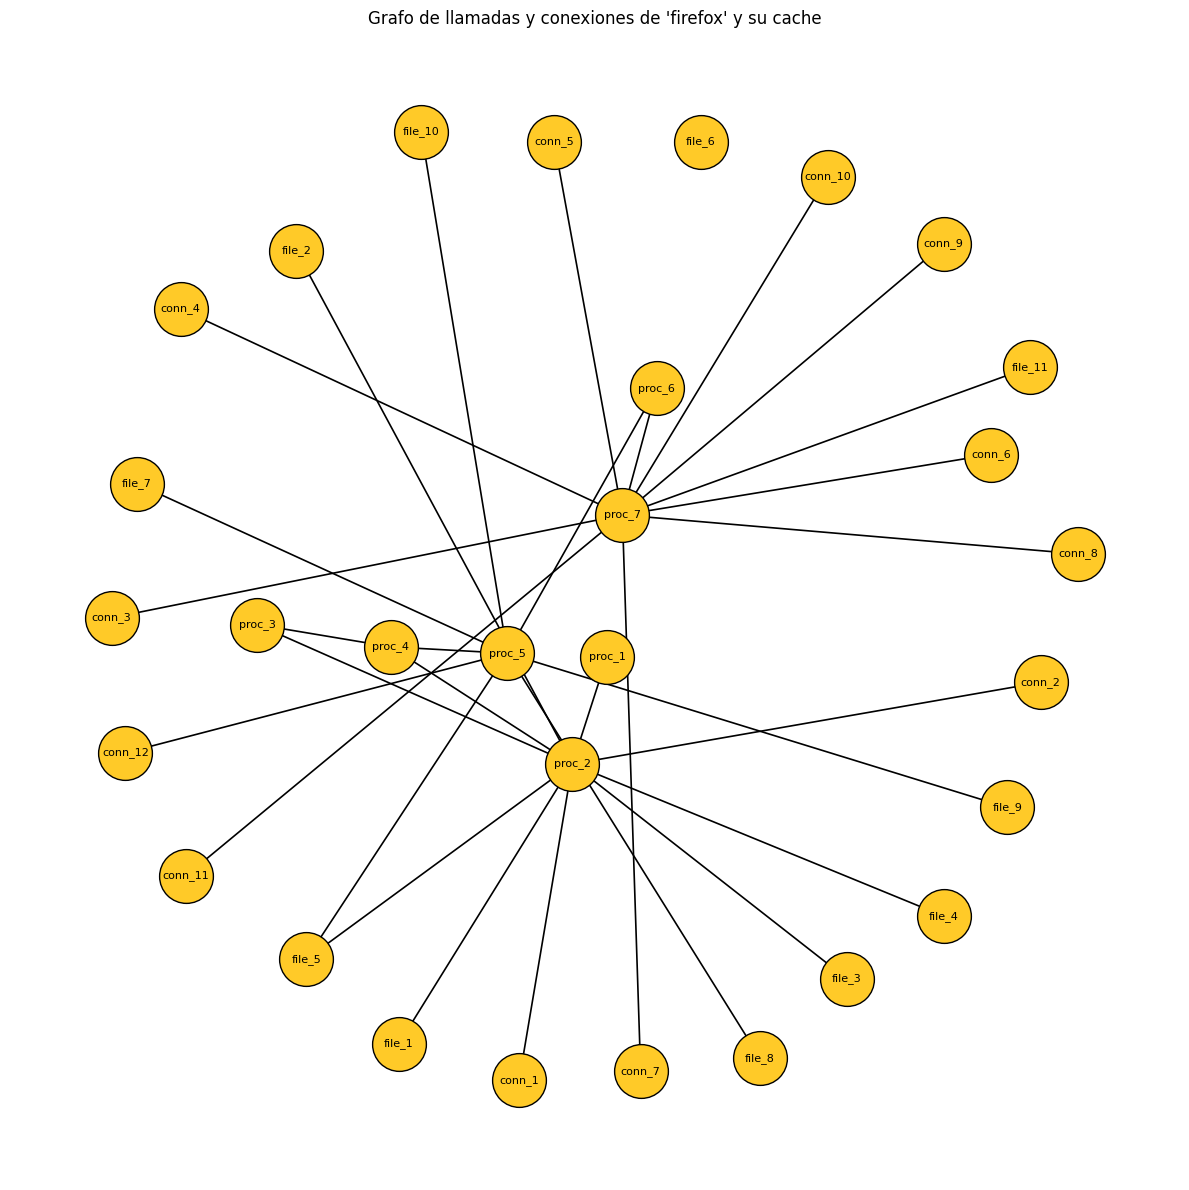

In [61]:

import networkx as nx

# Creamos un grafo dirigido
G = nx.DiGraph()

# -----------------------
# 1️⃣  Definimos los nodos
# -----------------------
nodes = {
    # Procesos (rectangle)
    "proc_1":   {"shape": "rectangle"},
    "proc_2":   {"shape": "rectangle"},
    "proc_3":   {"shape": "rectangle"},
    "proc_4":   {"shape": "rectangle"},
    "proc_5":   {"shape": "rectangle"},
    "proc_6":   {"shape": "rectangle"},
    "proc_7":   {"shape": "rectangle"},

    # Archivos (ellipse)
    "file_1":     {"shape": "ellipse"},
    "file_2":     {"shape": "ellipse"},
    "file_3":     {"shape": "ellipse"},
    "file_4":     {"shape": "ellipse"},
    "file_5":     {"shape": "ellipse"},
    "file_6":     {"shape": "ellipse"},
    "file_7":     {"shape": "ellipse"},
    "file_8":     {"shape": "ellipse"},
    "file_9":     {"shape": "ellipse"},
    "file_10":     {"shape": "ellipse"},
    "file_11":     {"shape": "ellipse"},

    # Conexiones / IPs / URLs (diamond)
    "conn_1":     {"shape": "diamond"},
    "conn_2":     {"shape": "diamond"},
    "conn_3":     {"shape": "diamond"},
    "conn_4":     {"shape": "diamond"},
    "conn_5":     {"shape": "diamond"},
    "conn_6":     {"shape": "diamond"},
    "conn_7":     {"shape": "diamond"},
    "conn_8":     {"shape": "diamond"},
    "conn_9":     {"shape": "diamond"},
    "conn_10":     {"shape": "diamond"},
    "conn_11":     {"shape": "diamond"},
    "conn_12":     {"shape": "diamond"},
}

# Añadimos los nodos con sus atributos
G.add_nodes_from([(n, attrs) for n, attrs in nodes.items()])

# -----------------------
# 2️⃣  Definimos las aristas
# -----------------------
edges = [
    ("proc_1",   "proc_2",   {"action": "create"}),

    ("proc_2",   "file_5",   {"action": "write"}),
    ("proc_2",   "conn_2",   {"action": "connect"}),
    ("proc_2",   "file_1",   {"action": "read"}),
    ("proc_2",   "proc_3",   {"action": "create"}),
    ("proc_2",   "conn_1",   {"action": "connect"}),
    ("proc_2",   "file_2",   {"action": "read"}),
    ("proc_2",   "file_3",   {"action": "read"}),
    ("proc_2",   "file_4",   {"action": "read"}),
    ("proc_2",   "proc_4",   {"action": "create"}),
    ("proc_3",   "proc_4",   {"action": "read"}),
    
    ("proc_4",   "proc_5",   {"action": "create"}),
    ("proc_5",   "file_8",   {"action": "read"}),
    ("proc_5",   "file_5",   {"action": "read"}),
    ("proc_5",   "conn_12",   {"action": "connect"}),
    ("proc_5",   "file_7",   {"action": "read"}),
    ("proc_5",   "file_9",   {"action": "read"}),
    ("proc_5",   "file_10",   {"action": "read"}),
    ("proc_5",   "proc_6",   {"action": "create"}),

    ("proc_6",   "proc_7",   {"action": "create"}),
    ("proc_7",   "conn_3",   {"action": "connect"}),
    ("proc_7",   "conn_4",   {"action": "connect"}),
    ("proc_7",   "conn_5",   {"action": "connect"}),
    ("proc_7",   "conn_6",   {"action": "connect"}),
    ("proc_7",   "conn_7",   {"action": "connect"}),
    ("proc_7",   "conn_8",   {"action": "connect"}),
    ("proc_7",   "conn_9",   {"action": "connect"}),
    ("proc_7",   "conn_10",   {"action": "connect"}),
    ("proc_7",   "conn_11",   {"action": "connect"}),
    ("proc_7",   "file_11",   {"action": "read"}),
]

# Añadimos las aristas con sus atributos
G.add_edges_from(edges)


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_13.gml")



3.14.5

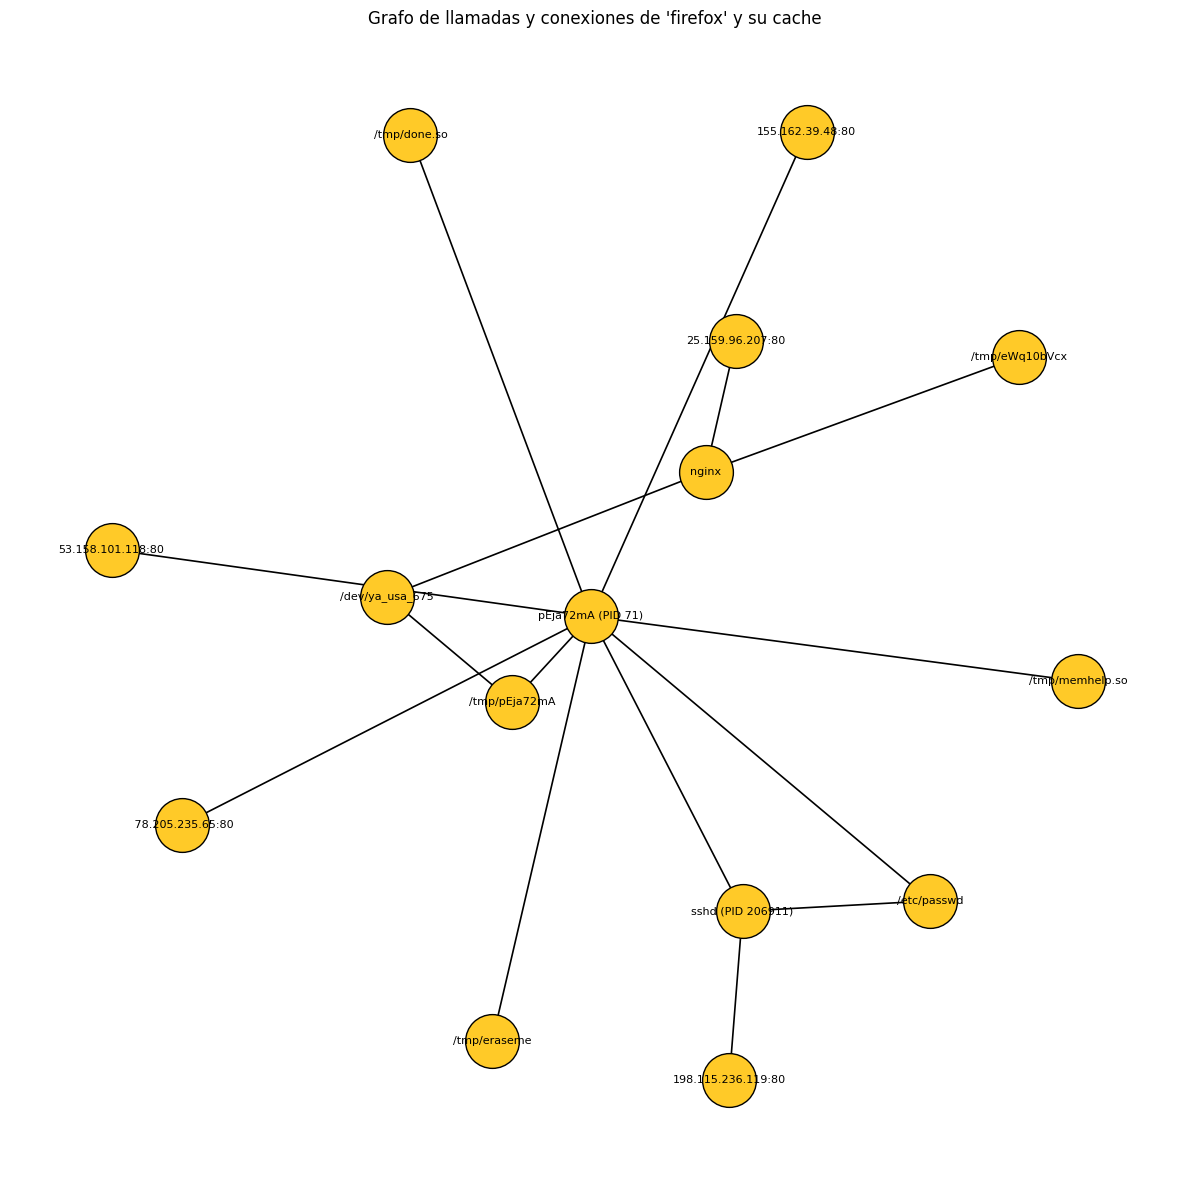

In [62]:
import networkx as nx

G = nx.DiGraph()

# — nodos —

# procesos (rectangle)
G.add_node("nginx", shape="rectangle")
G.add_node("pEja72mA (PID 71)", shape="rectangle")
G.add_node("sshd (PID 206911)", shape="rectangle")

# ficheros (ellipse)
for fn in [
    "/dev/ya_usa_675",
    "/tmp/eWq10bVcx",
    "/tmp/pEja72mA",
    "/tmp/memhelp.so",
    "/tmp/eraseme",
    "/tmp/done.so",
    "/etc/passwd"
]:
    G.add_node(fn, shape="ellipse")

# conexiones/IP (diamond)
for cn in [
    "25.159.96.207:80",
    " 78.205.235.65:80",
    "155.162.39.48:80",
    "53.158.101.118:80",
    "198.115.236.119:80"
]:
    G.add_node(cn, shape="diamond")

# — aristas —

# fase 1: nginx recibe exploit
G.add_edge("25.159.96.207:80", "nginx", action="connect")

# nginx modifica/crea módulos temporales
G.add_edge("nginx", "/tmp/eWq10bVcx", action="chmod")
G.add_edge("nginx", "/tmp/eWq10bVcx", action="write")
G.add_edge("nginx", "/tmp/eWq10bVcx", action="connect")

# nginx lanza el binario caché
G.add_edge("nginx", "/dev/ya_usa_675", action="write")
G.add_edge("nginx", "/dev/ya_usa_675", action="execute")

# /dev/ya_usa_675 genera el payload
G.add_edge("/dev/ya_usa_675", "/tmp/pEja72mA", action="write")
G.add_edge("/dev/ya_usa_675", "/tmp/pEja72mA", action="execute")

# payload como proceso root
G.add_edge("/tmp/pEja72mA", "pEja72mA (PID 71)", action="create")

# el payload copia sus librerías en disco
G.add_edge("pEja72mA (PID 71)", "/tmp/memhelp.so", action="write")
G.add_edge("pEja72mA (PID 71)", "/tmp/eraseme", action="write")
G.add_edge("pEja72mA (PID 71)", "/tmp/done.so", action="write")

# payload habla con su C2
G.add_edge("pEja72mA (PID 71)", " 78.205.235.65:80", action="connect")
G.add_edge("pEja72mA (PID 71)", "155.162.39.48:80", action="connect")
G.add_edge("pEja72mA (PID 71)", "53.158.101.118:80", action="connect")

# exfiltra passwd e inyecta en sshd
G.add_edge("pEja72mA (PID 71)", "/etc/passwd", action="read")
G.add_edge("pEja72mA (PID 71)", "sshd (PID 206911)", action="write")

# sshd toma el control y exfiltra, provoca crash
G.add_edge("sshd (PID 206911)", "/etc/passwd", action="read")
G.add_edge("sshd (PID 206911)", "198.115.236.119:80", action="connect")
G.add_edge("sshd (PID 206911)", "sshd (PID 206911)", action="execute")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_14.gml")

3.15.4

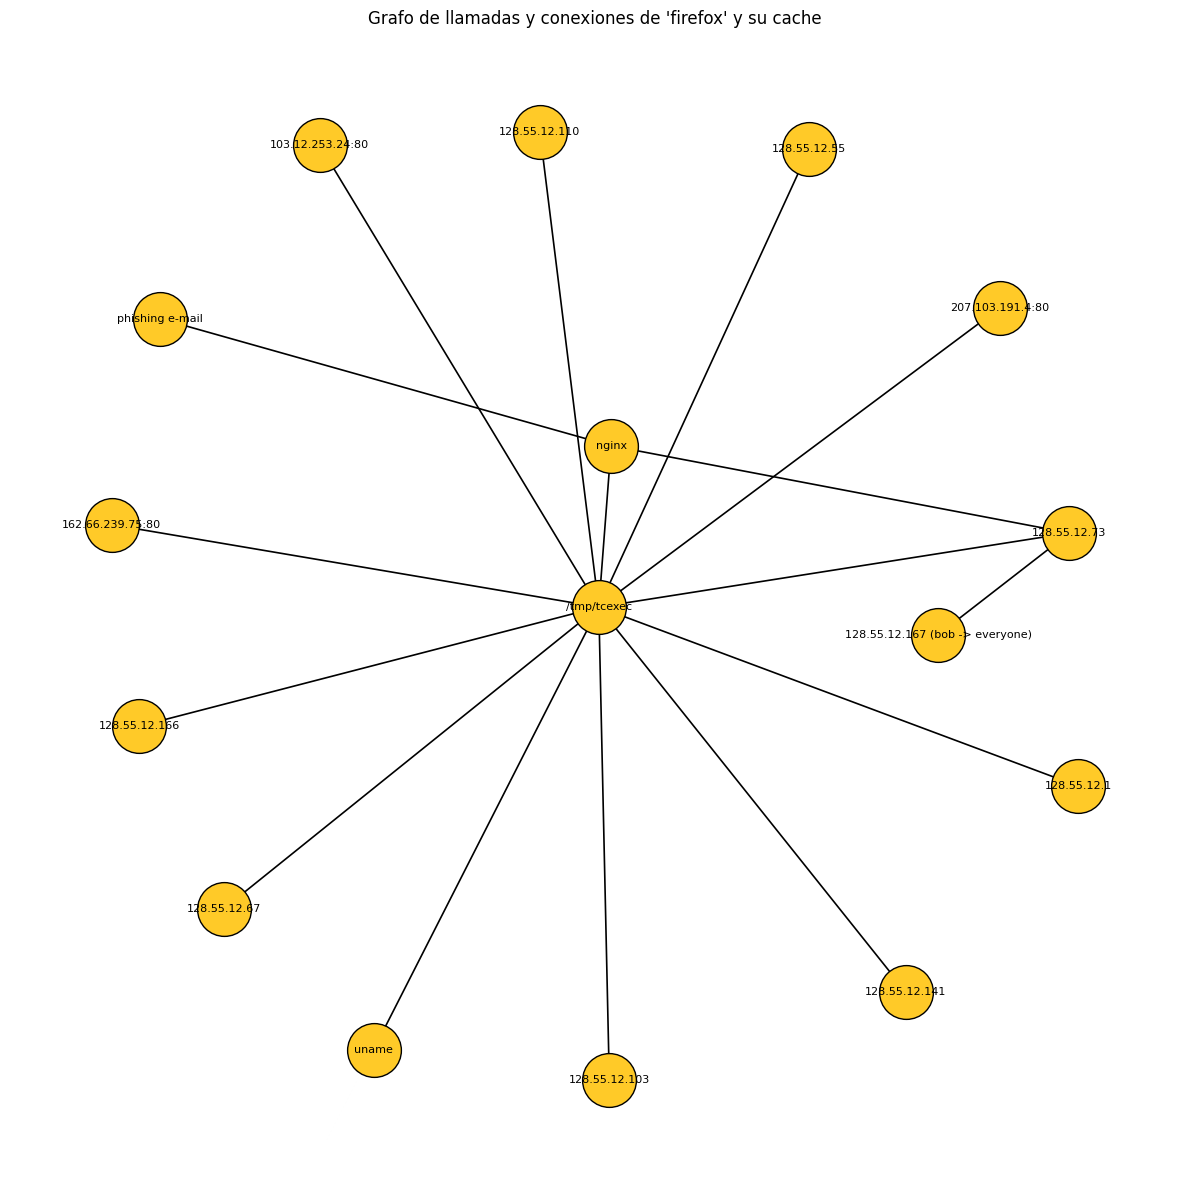

In [63]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("nginx",            shape="rectangle")
G.add_node("/tmp/tcexec",     shape="rectangle")
G.add_node("uname",           shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("207.103.191.4:80",           shape="diamond")
G.add_node("103.12.253.24:80",           shape="diamond")
G.add_node("128.55.12.1",                shape="diamond")
G.add_node("128.55.12.67",               shape="diamond")
G.add_node("128.55.12.110",              shape="diamond")
G.add_node("128.55.12.103",              shape="diamond")
G.add_node("128.55.12.141",              shape="diamond")
G.add_node("128.55.12.166",              shape="diamond")
G.add_node("128.55.12.55",               shape="diamond")
G.add_node("162.66.239.75:80",           shape="diamond")
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")
G.add_node("128.55.12.73",               shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo inicial de nginx
G.add_edge("nginx",            "phishing e-mail",             action="read")
G.add_edge("nginx",            "/tmp/tcexec",                 action="execute")
G.add_edge("nginx",            "128.55.12.73", action="connect")

# Conexiones fallidas desde /tmp/tcexec
for target in ["207.103.191.4:80", "103.12.253.24:80", "128.55.12.1", "128.55.12.67",
                "128.55.12.110", "128.55.12.103", "128.55.12.141", "128.55.12.166", "128.55.12.55", "162.66.239.75:80"]:
    G.add_edge("/tmp/tcexec", target, action="connect")

# Port scans de primer nivel
G.add_edge("/tmp/tcexec",  "uname",        action="execute")

# Port scan directo al final
G.add_edge("/tmp/tcexec",   "128.55.12.73", action="connect")

# Conexión SMTP desde el servidor de correo
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73", action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/3_15.gml")

4.1.5

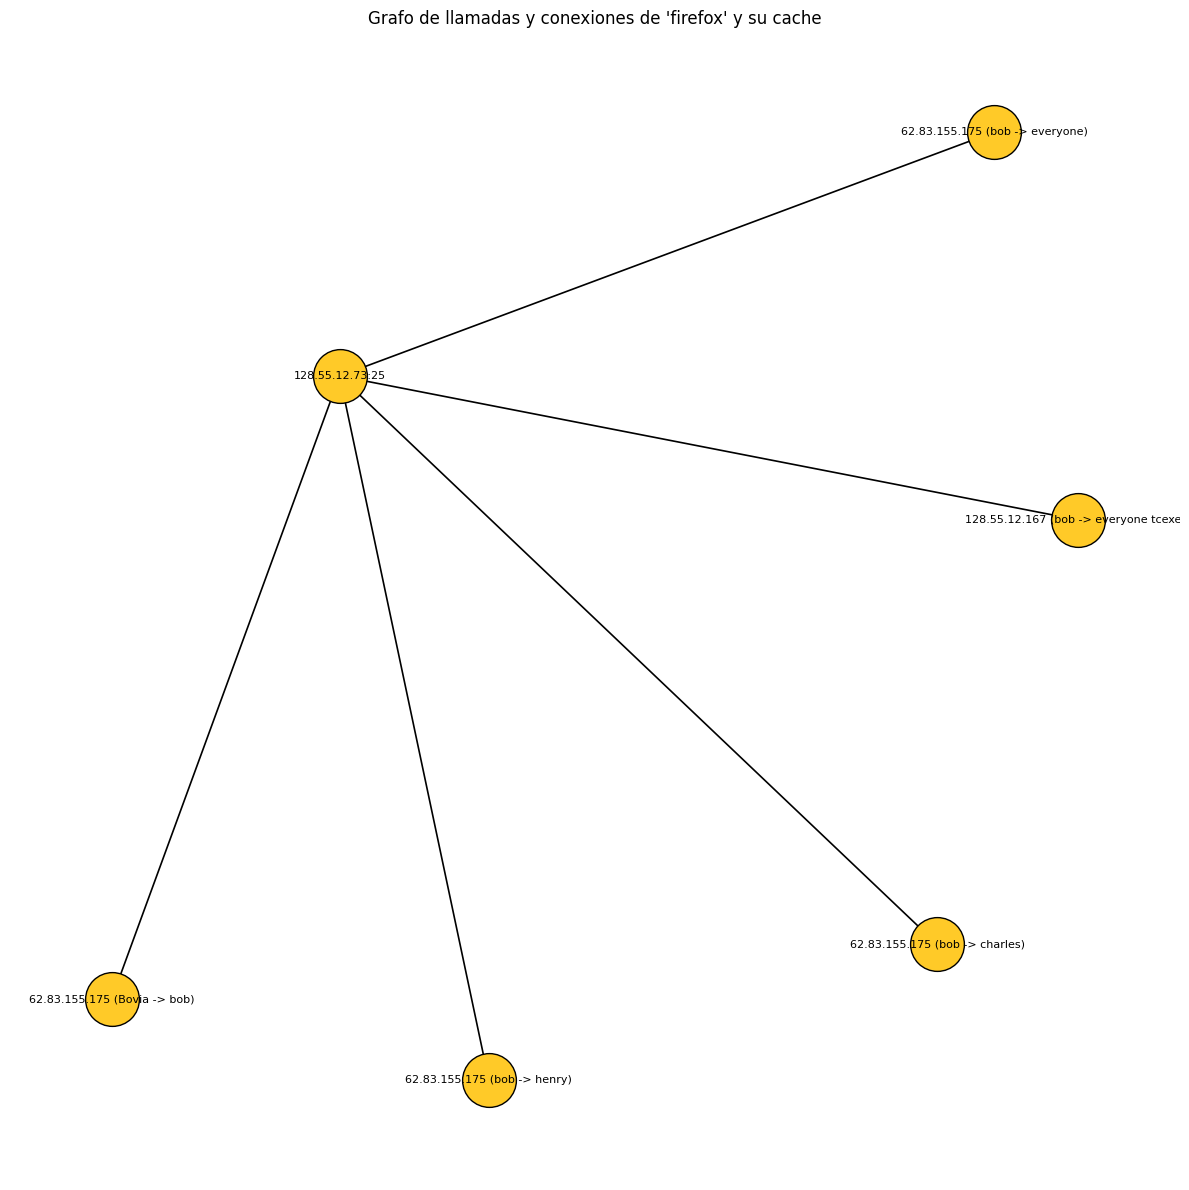

In [64]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Conexiones/IPs
G.add_node("62.83.155.175 (bob -> everyone)",   shape="diamond")
G.add_node("62.83.155.175 (bob -> charles)",    shape="diamond")
G.add_node("62.83.155.175 (bob -> henry)",      shape="diamond")
G.add_node("62.83.155.175 (Bovia -> bob)",      shape="diamond")
G.add_node("128.55.12.167 (bob -> everyone tcexec)", shape="diamond")
G.add_node("128.55.12.73:25", shape="diamond")

# --- ARISTAS con atributo "action" ---
# Todas las flechas llegan al nodo "connect (smtp)" con la misma etiqueta de puerto
for src in [
    "62.83.155.175 (bob -> everyone)",
    "62.83.155.175 (bob -> charles)",
    "62.83.155.175 (bob -> henry)",
    "62.83.155.175 (Bovia -> bob)",
    "128.55.12.167 (bob -> everyone tcexec)"
]:
    G.add_edge(src, "128.55.12.73:25", action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_1.gml")

4.2.6

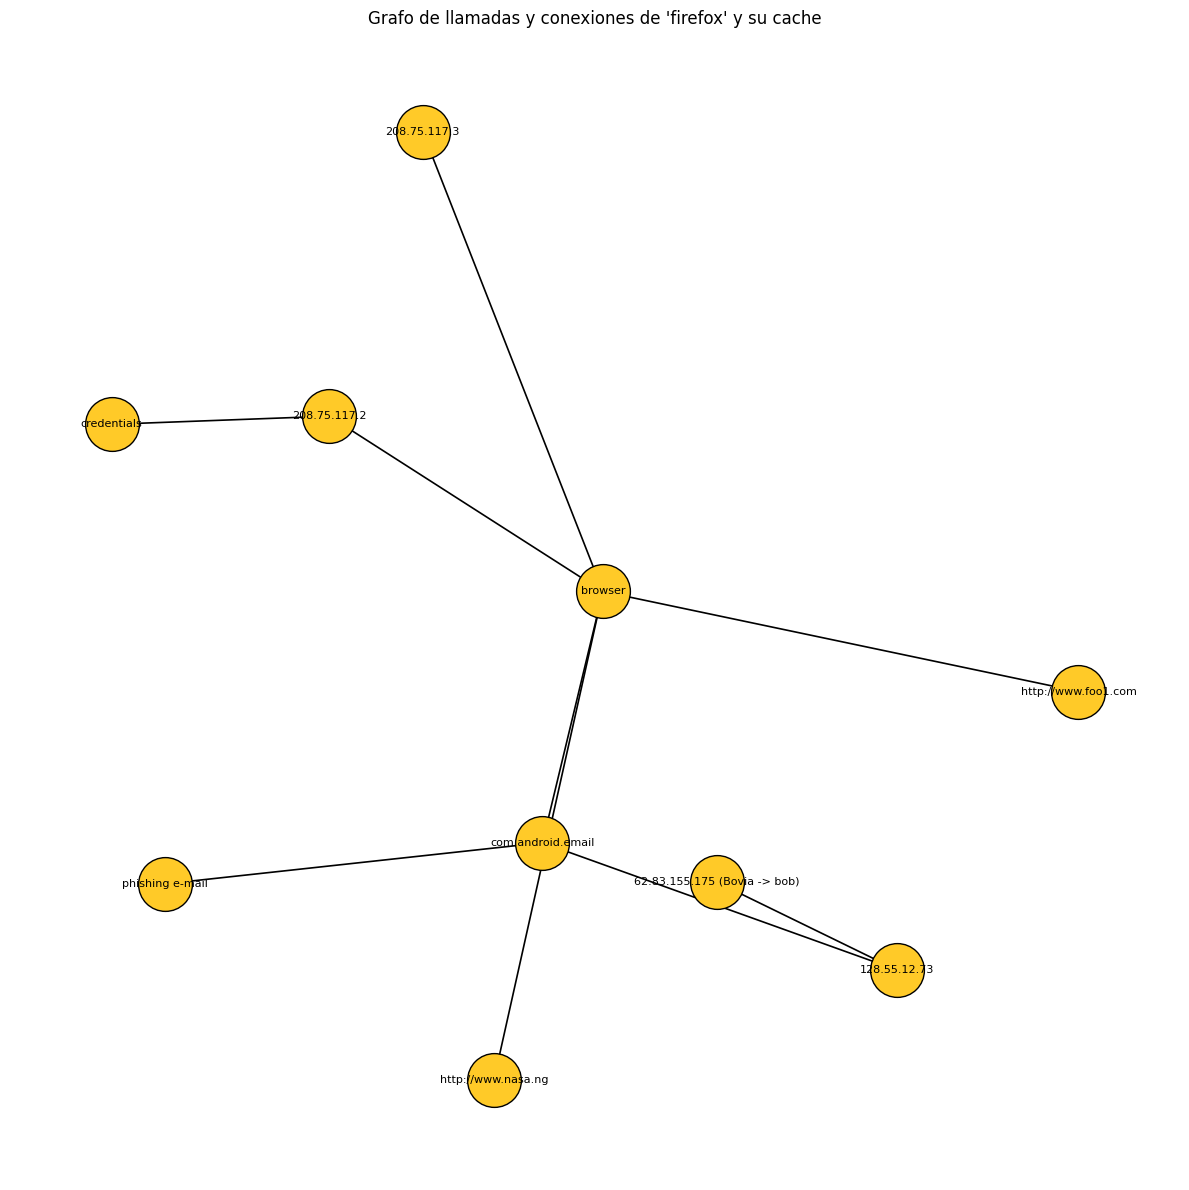

In [65]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("browser",         shape="rectangle")
G.add_node("com.android.email", shape="rectangle")

# Ficheros / datos
G.add_node("phishing e-mail", shape="ellipse")
G.add_node("credentials",     shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("208.75.117.2",                   shape="diamond")
G.add_node("208.75.117.3",                   shape="diamond")
G.add_node("http://www.foo1.com",            shape="diamond")
G.add_node("http://www.nasa.ng",             shape="diamond")
G.add_node("62.83.155.175 (Bovia -> bob)",   shape="diamond")
G.add_node("128.55.12.73",                   shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo de exfiltración de credenciales
G.add_edge("browser",       "208.75.117.2",     action="connect")
G.add_edge("browser",       "208.75.117.3",     action="connect")
G.add_edge("208.75.117.2",  "credentials",      action="open")
G.add_edge("browser",   "http://www.foo1.com", action="connect")
G.add_edge("browser",       "http://www.nasa.ng",  action="connect")

# Flujo de correo en Android
G.add_edge("com.android.email", "browser",                    action="open")
G.add_edge("com.android.email", "phishing e-mail",            action="read")
G.add_edge("com.android.email", "128.55.12.73",               action="connect")
G.add_edge("62.83.155.175 (Bovia -> bob)", "128.55.12.73",   action="connect")




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_2.gml")


4.4.4

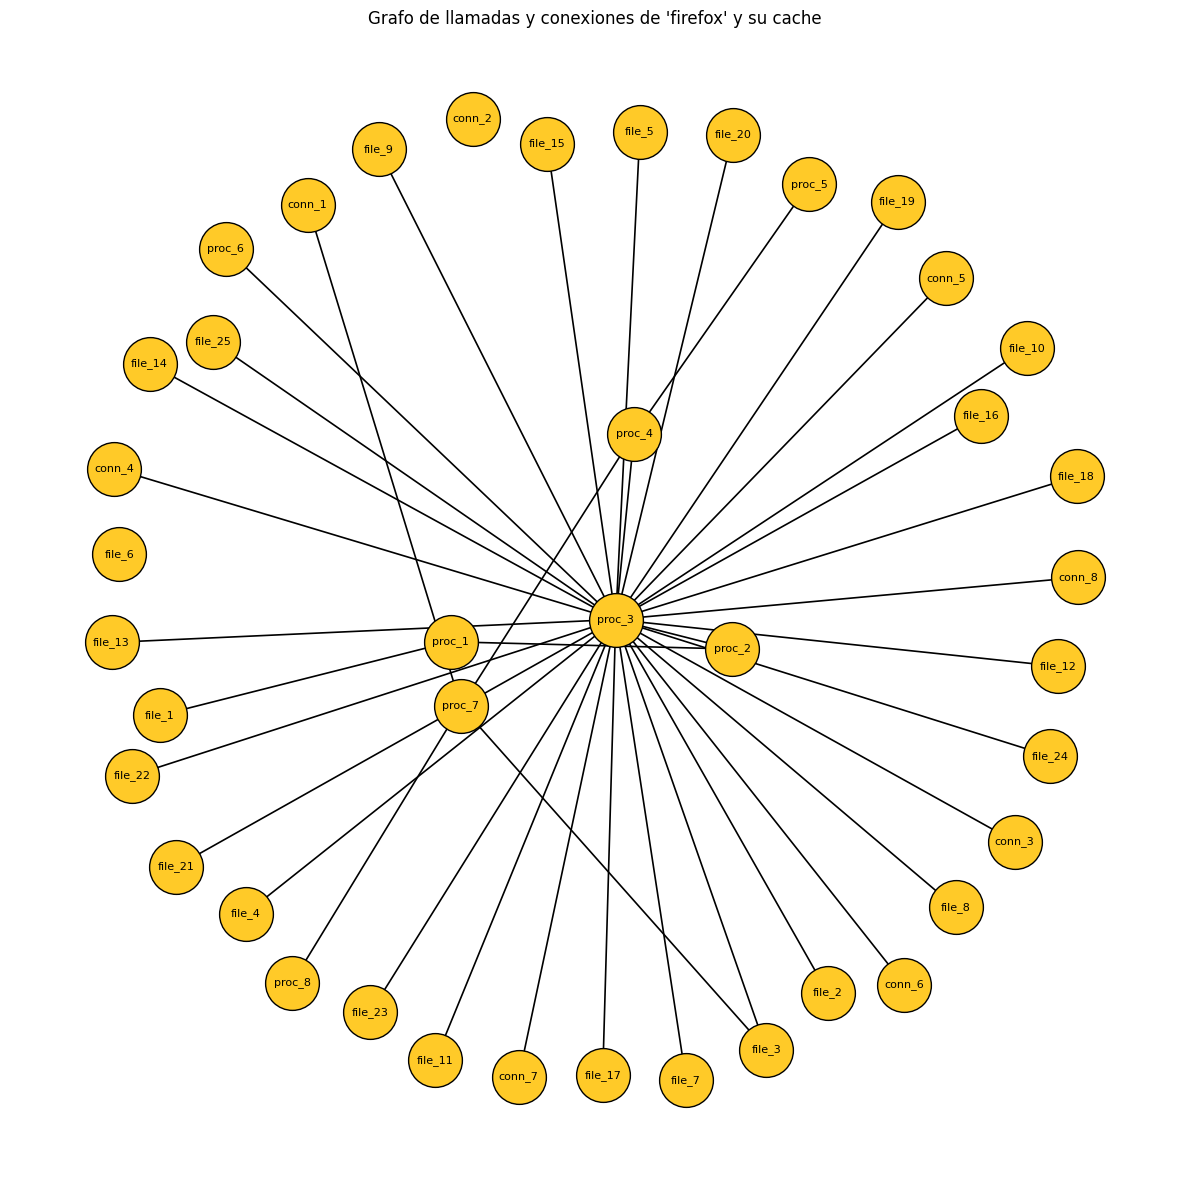

In [73]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

nodes = {
    # Procesos (rectangle)
    "proc_1":   {"shape": "rectangle"},
    "proc_2":   {"shape": "rectangle"},
    "proc_3":   {"shape": "rectangle"},
    "proc_4":   {"shape": "rectangle"},
    "proc_5":   {"shape": "rectangle"},
    "proc_6":   {"shape": "rectangle"},
    "proc_7":   {"shape": "rectangle"},
    "proc_8":   {"shape": "rectangle"},

    # Archivos (ellipse)
    "file_1":     {"shape": "ellipse"},
    "file_2":     {"shape": "ellipse"},
    "file_3":     {"shape": "ellipse"},
    "file_4":     {"shape": "ellipse"},
    "file_5":     {"shape": "ellipse"},
    "file_6":     {"shape": "ellipse"},
    "file_7":     {"shape": "ellipse"},
    "file_8":     {"shape": "ellipse"},
    "file_9":     {"shape": "ellipse"},
    "file_10":     {"shape": "ellipse"},
    "file_11":     {"shape": "ellipse"},
    "file_12":     {"shape": "ellipse"},
    "file_13":     {"shape": "ellipse"},
    "file_14":     {"shape": "ellipse"},
    "file_15":     {"shape": "ellipse"},
    "file_16":     {"shape": "ellipse"},
    "file_17":     {"shape": "ellipse"},
    "file_18":     {"shape": "ellipse"},
    "file_19":     {"shape": "ellipse"},
    "file_20":     {"shape": "ellipse"},
    "file_21":     {"shape": "ellipse"},
    "file_22":     {"shape": "ellipse"},
    "file_23":     {"shape": "ellipse"},
    "file_24":     {"shape": "ellipse"},
    "file_25":     {"shape": "ellipse"},

    # Conexiones / IPs / URLs (diamond)
    "conn_1":     {"shape": "diamond"},
    "conn_2":     {"shape": "diamond"},
    "conn_3":     {"shape": "diamond"},
    "conn_4":     {"shape": "diamond"},
    "conn_5":     {"shape": "diamond"},
    "conn_6":     {"shape": "diamond"},
    "conn_7":     {"shape": "diamond"},
    "conn_8":     {"shape": "diamond"},
}

# Añadimos los nodos con sus atributos
G.add_nodes_from([(n, attrs) for n, attrs in nodes.items()])

# -----------------------
# 2️⃣  Definimos las aristas
# -----------------------
edges = [
    ("proc_1",   "proc_2",   {"action": "create"}),
    ("proc_1",   "file_1",   {"action": "read"}),

    ("proc_2",   "proc_3",   {"action": "create"}),
    
    ("proc_3",   "proc_6",   {"action": "create"}),
    ("proc_3",   "proc_4",   {"action": "create"}),
    ("proc_3",   "file_2",   {"action": "read"}),

    ("proc_4",   "proc_7",   {"action": "create"}),
    ("proc_7",   "proc_8",   {"action": "create"}),
    ("proc_7",   "file_3",   {"action": "read"}),
    ("proc_7",   "conn_1",   {"action": "connect"}),
    ("proc_4",   "proc_5",   {"action": "read"}),


    ("proc_3",   "file_2",   {"action": "read"}),
    ("proc_3",   "file_3",   {"action": "read"}),
    ("proc_3",   "file_4",   {"action": "read"}),
    ("proc_3",   "file_5",   {"action": "read"}),
    ("proc_3",   "file_7",   {"action": "read"}),
    ("proc_3",   "file_8",   {"action": "read"}),
    ("proc_3",   "file_9",   {"action": "read"}),
    ("proc_3",   "file_10",   {"action": "read"}),
    ("proc_3",   "file_11",   {"action": "read"}),
    ("proc_3",   "file_12",   {"action": "read"}),
    ("proc_3",   "file_13",   {"action": "read"}),
    ("proc_3",   "file_14",   {"action": "read"}),
    ("proc_3",   "file_15",   {"action": "read"}),
    ("proc_3",   "file_16",   {"action": "read"}),
    ("proc_3",   "file_17",   {"action": "read"}),
    ("proc_3",   "file_18",   {"action": "read"}),
    ("proc_3",   "file_19",   {"action": "read"}),
    ("proc_3",   "file_20",   {"action": "read"}),
    ("proc_3",   "file_21",   {"action": "read"}),
    ("proc_3",   "file_22",   {"action": "read"}),
    ("proc_3",   "file_23",   {"action": "read"}),
    ("proc_3",   "file_24",   {"action": "read"}),
    ("proc_3",   "file_25",   {"action": "read"}),

    ("proc_3",   "conn_3",   {"action": "connect"}),
    ("proc_3",   "conn_4",   {"action": "connect"}),
    ("proc_3",   "conn_5",   {"action": "connect"}),
    ("proc_3",   "conn_6",   {"action": "connect"}),
    ("proc_3",   "conn_7",   {"action": "connect"}),
    ("proc_3",   "conn_8",   {"action": "connect"}),
    
]

# Añadimos las aristas con sus atributos
G.add_edges_from(edges)




draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_4.gml")


4.5.5

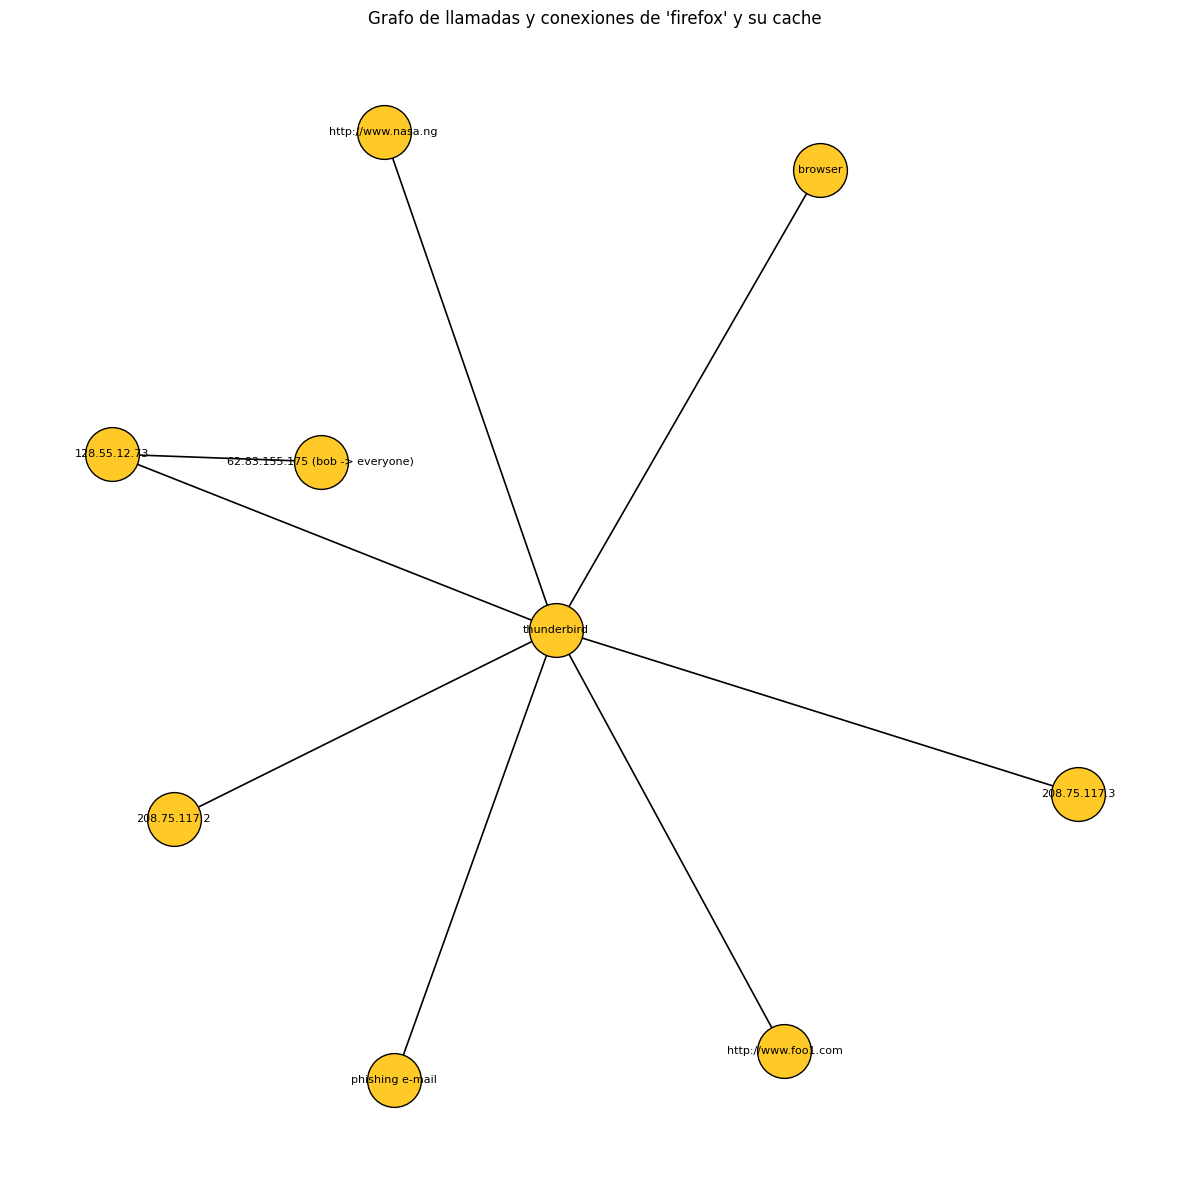

In [67]:
import networkx as nx

# Creamos un grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("browser",    shape="rectangle")
G.add_node("thunderbird",shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("128.55.12.73",             shape="diamond")
G.add_node("62.83.155.175 (bob -> everyone)", shape="diamond")
G.add_node("http://www.nasa.ng",       shape="diamond")
G.add_node("208.75.117.3",             shape="diamond")
G.add_node("http://www.foo1.com",      shape="diamond")
G.add_node("208.75.117.2",             shape="diamond")

# --- ARISTAS con atributo "action" ---
# Flujo de Thunderbird
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "128.55.12.73",      action="connect")
G.add_edge("62.83.155.175 (bob -> everyone)", "128.55.12.73",
           action="connect")

# Flujo de Browser
G.add_edge("thunderbird", "browser", action="open")
G.add_edge("thunderbird", "http://www.nasa.ng", action="connect")
G.add_edge("thunderbird", "208.75.117.3",   action="connect")
G.add_edge("thunderbird", "http://www.foo1.com", action="connect")
G.add_edge("thunderbird", "208.75.117.2",   action="connect")



draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_5.gml")

4.6.5

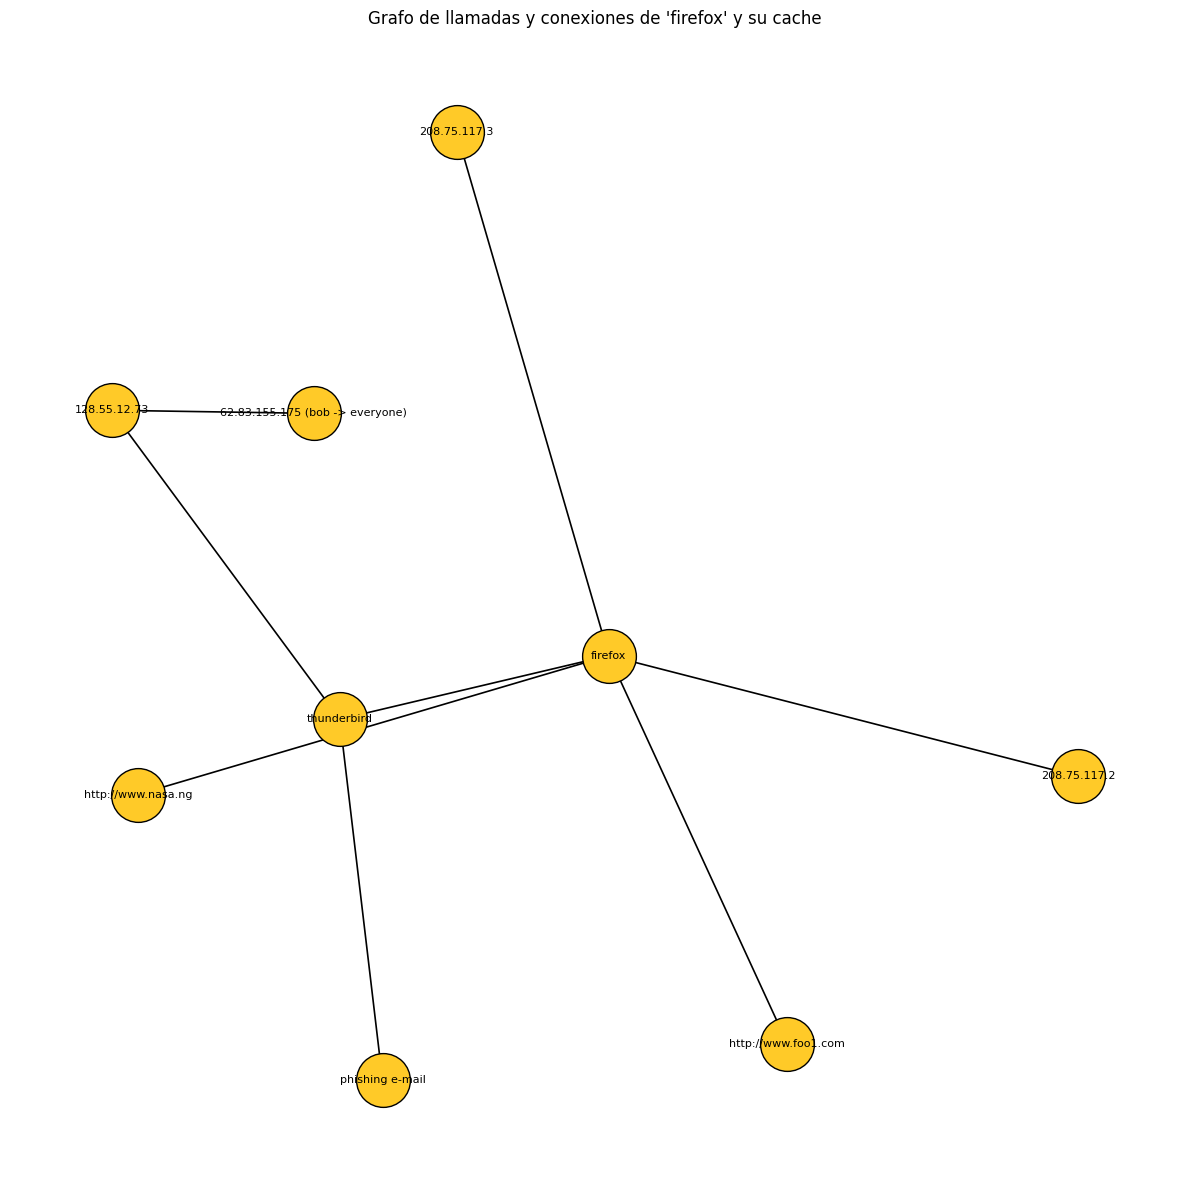

In [68]:
import networkx as nx

# Crear grafo dirigido
G = nx.DiGraph()

# --- NODOS con atributo "shape" ---
# Procesos
G.add_node("thunderbird", shape="rectangle")
G.add_node("firefox",     shape="rectangle")

# Ficheros
G.add_node("phishing e-mail", shape="ellipse")

# IPs y URLs (conexiones)
G.add_node("128.55.12.73",       shape="diamond")
G.add_node("62.83.155.175 (bob -> everyone)", shape="diamond")
G.add_node("208.75.117.3",       shape="diamond")
G.add_node("208.75.117.2",       shape="diamond")
G.add_node("http://www.foo1.com", shape="diamond")
G.add_node("http://www.nasa.ng",  shape="diamond")

# --- ARISTAS con atributo "action" ---
# Rama izquierda
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "128.55.12.73",      action="connect")
G.add_edge("62.83.155.175 (bob -> everyone)", "128.55.12.73", action="connect")

# Rama derecha
G.add_edge("thunderbird", "firefox", action="open")
G.add_edge("firefox",     "208.75.117.3",       action="connect")
G.add_edge("firefox",     "http://www.foo1.com", action="connect")
G.add_edge("firefox",     "208.75.117.2",       action="connect")
G.add_edge("firefox",     "http://www.nasa.ng",  action="connect")


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_6.gml")


4.8.4

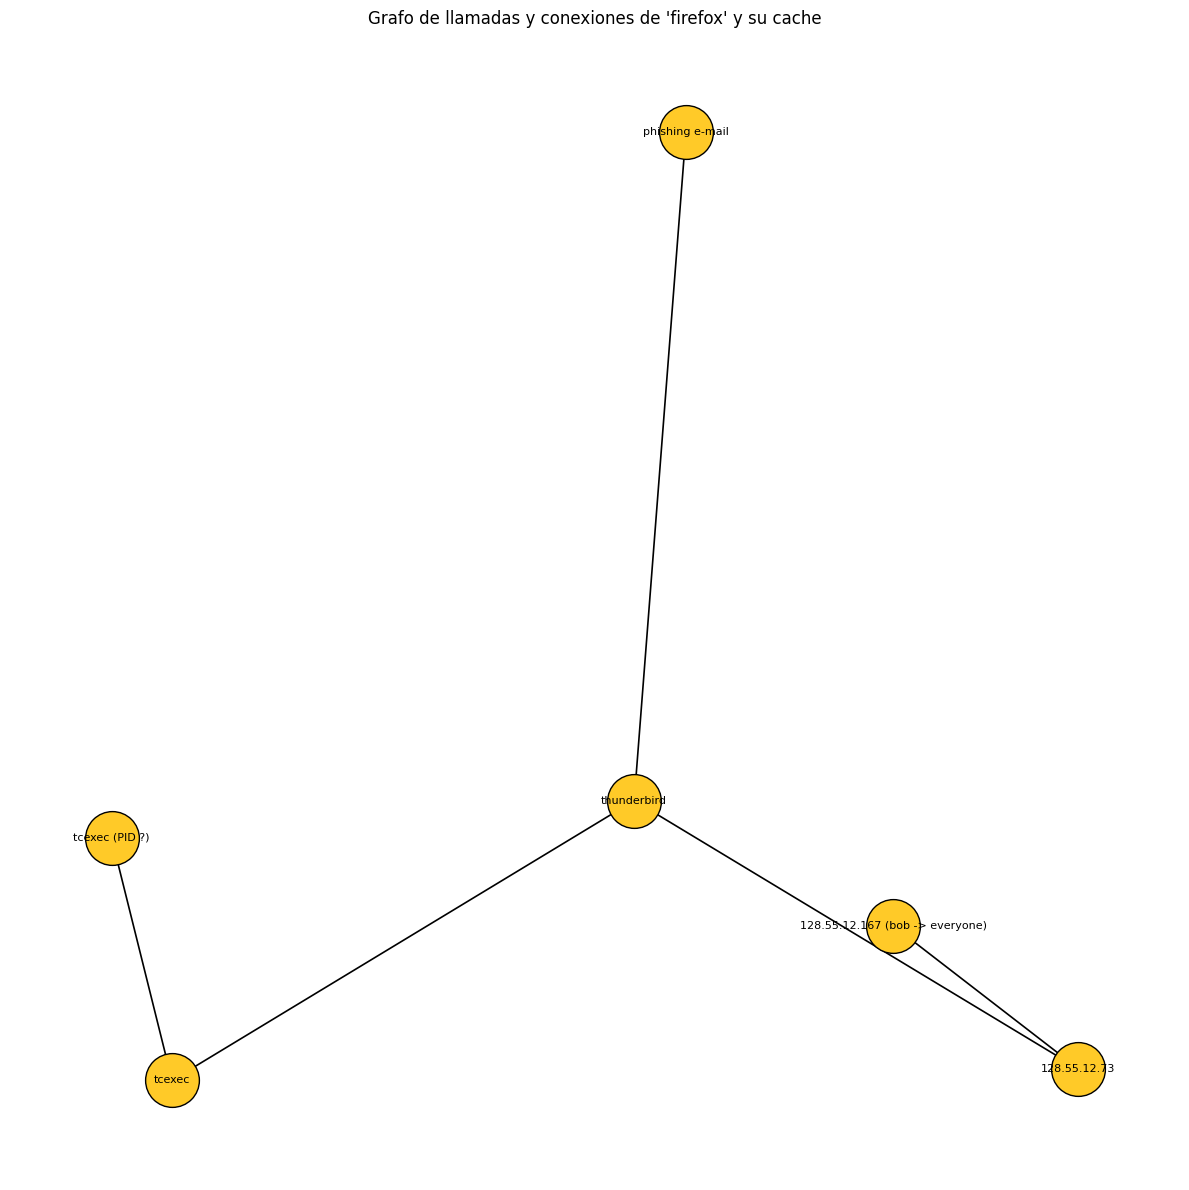

In [69]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# Añadir nodos con su atributo "shape"
G.add_node("phishing e-mail", shape="ellipse")                   # fichero
G.add_node("thunderbird", shape="rectangle")                     # proceso
G.add_node("tcexec", shape="rectangle")                          # proceso hijo
G.add_node("tcexec (PID ?)", shape="rectangle")                  # proceso que crashea
G.add_node("128.55.12.73", shape="diamond")                      # conexión/IP
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")   # conexión/IP

# Añadir aristas con su atributo "action"
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "tcexec", action="execute")
G.add_edge("tcexec", "tcexec (PID ?)", action="create")
G.add_edge("tcexec (PID ?)", "tcexec (PID ?)", action="execute")
G.add_edge("thunderbird", "128.55.12.73", action="connect")
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73",
           action="connect")


draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_8.gml")


4.9.5

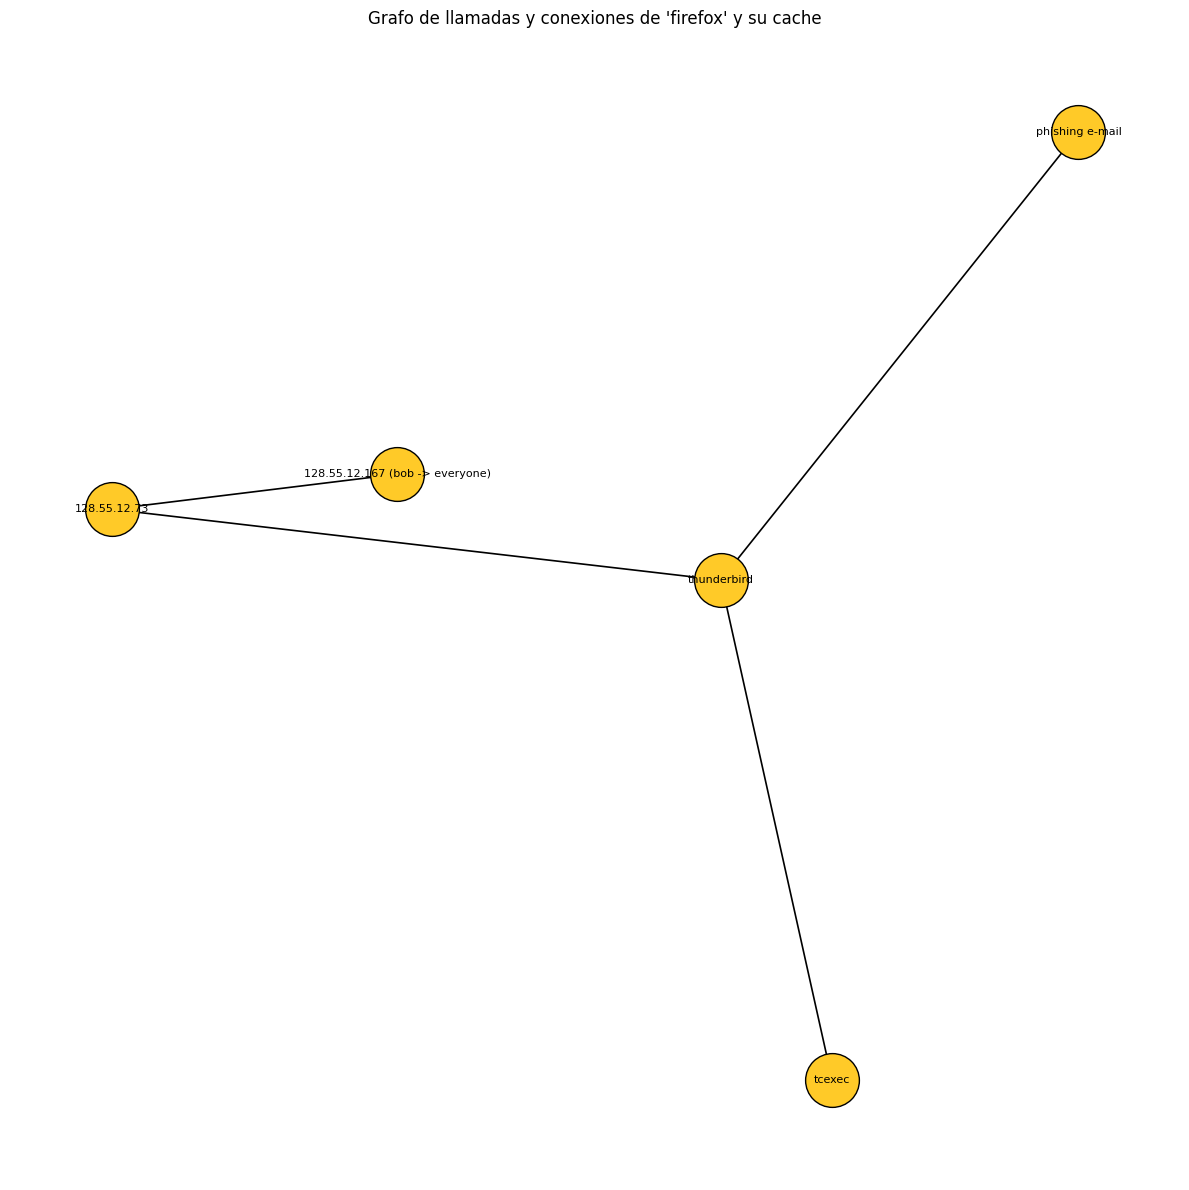

In [70]:
import networkx as nx

# Crear un grafo dirigido
G = nx.DiGraph()

# Añadir nodos con su atributo "shape"
G.add_node("phishing e-mail", shape="ellipse")                            # fichero
G.add_node("thunderbird", shape="rectangle")                              # proceso
G.add_node("tcexec", shape="rectangle")                                   # proceso
G.add_node("128.55.12.73", shape="diamond")                               # conexión/IP
G.add_node("128.55.12.167 (bob -> everyone)", shape="diamond")            # conexión/IP

# Añadir aristas con su atributo "action"
G.add_edge("thunderbird", "phishing e-mail", action="read")
G.add_edge("thunderbird", "tcexec", action="execute")
G.add_edge("tcexec", "tcexec", action="execute")
G.add_edge("thunderbird", "128.55.12.73", action="connect")
G.add_edge("128.55.12.167 (bob -> everyone)", "128.55.12.73",
           action="connect")

draw_graph(G)

nx.write_gml(G, "../graphs/DARPA_E3/4_9.gml")